In [1]:
OOS_START_YEAR = 2019
CUT_OUT_YEAR = 2024

## S&P500

In [226]:
import pandas as pd 
import numpy as np
sp500 = pd.read_parquet("data/sp500_tr.parquet")
sp500["date"] = pd.to_datetime(sp500["date"])

for n in [1, 5, 20, 252]:
    sp500[f"sp_ret_{n}"] = (
        sp500["adjusted_close"] / sp500["adjusted_close"].shift(n) - 1
    )

sp500["sp_c2o"] = sp500["open"].shift(-1) / sp500["close"] - 1

sp500 = sp500.drop(
    columns=["open", "high", "low", "close", "adjusted_close", "volume"],
    errors="ignore",
)



## 1000 yearly universe dict

In [2]:
import pickle

with open("data/eligible_dict.pkl", "rb") as f:
    eligible_dict = pickle.load(f)

In [3]:
import json

with open("processed/valid_feature_cols_by_year.json", "r") as f:
    valid_feature_cols_by_year = json.load(f)

valid_feature_cols_by_year = {
    int(year): cols
    for year, cols in valid_feature_cols_by_year.items()
}


## Set backtest year

In [4]:
universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

In [ ]:

df = pd.read_parquet("data/df_featured.parquet")
df_hardtoborrow = pd.read_parquet("data/df_hardtoborrow.parquet")
eligibility_50m = pd.read_parquet("data/eligibility_50m.parquet")
eligibility_250m = pd.read_parquet("data/eligibility_250m.parquet")
eligibility_1b = pd.read_parquet("data/eligibility_1b.parquet")
df

,instrument_id,date,open,high,low,close,volume,adj_factor,adjusted_open,adjusted_high,...,ADX_5,NATR_5,WILLR_20,CCI_20,ADX_20,NATR_20,WILLR_252,CCI_252,ADX_252,NATR_252
0,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1.939596,41.307375,42.509730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1.939597,42.645538,43.401787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1.939596,44.856262,50.325147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1.939592,41.908382,42.645427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1.939593,42.335100,43.013763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5218251,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,392000.0,0.784192,13.072481,13.158742,...,28.047631,2.730248,-70.212766,-77.848711,12.920911,2.895398,-82.266693,-115.983639,7.826062,3.181581
5218252,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,623900.0,0.784195,13.096048,13.166626,...,26.305573,2.495764,-70.744681,-69.074513,12.891537,2.829835,-82.365762,-114.015021,7.820017,3.177002
5218253,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,1044300.0,0.784192,13.237161,13.370473,...,23.739748,2.804569,-86.702128,-80.732511,12.515981,2.930232,-85.337824,-114.491275,7.812025,3.237378
5218254,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,916000.0,0.797518,13.079302,13.151079,...,21.319372,2.624728,-95.767196,-136.566997,12.401064,2.903565,-87.121062,-123.569239,7.805509,3.267252


## Seperate different kinds of features

In [6]:
# ============================================================
# Feature groups for modelling / ablation
# ============================================================

fundamental_cols = [
    "valuation_score",
    "quality_score",
    "health_score",
    "momentum_score",
    "final_score",
    "final_score_clean",
    "value_trap",
    "piot_norm",
]


earnings_revision_cols = [
    "epsp",
    "epsf",
    "reps1",
    "repsf4",
    "sue",
    "inesp",
    "inesn",
    "reps41",
    "repsfs",
    "repsfl",
    "deps",
]

returns_volatility_liquidity_cols = [
    "return_1",
    "return_5",
    "return_20",
    "overnight_return",
    "ret_std_20",
    "on_ret_std_20",
    "range_pct",
    "estimate_turnover",
    "twr_20",
    "volume_z_20",
    "dist_to_high_20",
    "dist_to_low_20",
    "channel_pos_20",
]


technical_indicator_cols = [
    "DEMA_open_5",
    "KAMA_open_5",
    "MIDPOINT_open_5",
    "LINEARREG_SLOPE_open_5",
    "DEMA_open_20",
    "KAMA_open_20",
    "MIDPOINT_open_20",
    "LINEARREG_SLOPE_open_20",
    "HT_DCPHASE_open",

    "DEMA_high_5",
    "KAMA_high_5",
    "MIDPOINT_high_5",
    "LINEARREG_SLOPE_high_5",
    "DEMA_high_20",
    "KAMA_high_20",
    "MIDPOINT_high_20",
    "LINEARREG_SLOPE_high_20",
    "HT_DCPHASE_high",

    "DEMA_low_5",
    "KAMA_low_5",
    "MIDPOINT_low_5",
    "LINEARREG_SLOPE_low_5",
    "DEMA_low_20",
    "KAMA_low_20",
    "MIDPOINT_low_20",
    "LINEARREG_SLOPE_low_20",
    "HT_DCPHASE_low",

    "DEMA_close_5",
    "KAMA_close_5",
    "MIDPOINT_close_5",
    "LINEARREG_SLOPE_close_5",
    "DEMA_close_20",
    "KAMA_close_20",
    "MIDPOINT_close_20",
    "LINEARREG_SLOPE_close_20",
    "HT_DCPHASE_close",

    "DEMA_volume_5",
    "KAMA_volume_5",
    "MIDPOINT_volume_5",
    "LINEARREG_SLOPE_volume_5",
    "DEMA_volume_20",
    "KAMA_volume_20",
    "MIDPOINT_volume_20",
    "LINEARREG_SLOPE_volume_20",
    "HT_DCPHASE_volume",

    "WILLR_5",
    "CCI_5",
    "ADX_5",
    "NATR_5",
    "WILLR_20",
    "CCI_20",
    "ADX_20",
    "NATR_20",
]



short_interest_cols = [
    "dsi",
    "dtcn",
    "ddtcn",
]

In [8]:
feature_groups = {
    "fundamental": fundamental_cols,
    "returns_volatility_liquidity": returns_volatility_liquidity_cols,
    "technical_indicator": technical_indicator_cols,
    "short_interest": short_interest_cols,
}


In [9]:
base_cols = [
    "instrument_id",
    "date",
    "market_cap",
    "gics_industry",
]

feature_cols = [
    col
    for group_cols in feature_groups.values()
    for col in group_cols
]

target_cols = [
    "target_c2o_next_adj",
]

selected_cols = base_cols + feature_cols + target_cols

# 保險：只留 df 裡真的存在的欄位
selected_cols = [c for c in selected_cols if c in df.columns]

df = df[selected_cols].copy()

df

,instrument_id,date,market_cap,gics_industry,valuation_score,quality_score,health_score,momentum_score,final_score,final_score_clean,...,ADX_5,NATR_5,WILLR_20,CCI_20,ADX_20,NATR_20,dsi,dtcn,ddtcn,target_c2o_next_adj
0,1,2013-12-12,2.116608e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046608
1,1,2013-12-13,2.175675e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004181
2,1,2013-12-16,2.118577e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000917
3,1,2013-12-17,2.147131e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003663
4,1,2013-12-18,2.149100e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5218251,1611,2022-12-23,2.903138e+09,601010.0,-0.045794,0.301289,-1.340432,-0.430755,-1.133956,-1.133956,...,28.047631,2.730248,-70.212766,-77.848711,12.920911,2.895398,0.088148,20.888611,12.413199,0.007157
5218252,1611,2022-12-27,2.901407e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.126558,-1.126558,...,26.305573,2.495764,-70.744681,-69.074513,12.891537,2.829835,0.088148,20.888611,12.413199,0.013287
5218253,1611,2022-12-28,2.849472e+09,601010.0,-0.049836,0.290034,-1.339772,-0.394678,-1.120579,-1.120579,...,23.739748,2.804569,-86.702128,-80.732511,12.515981,2.930232,0.088148,20.888611,12.413199,-0.003077
5218254,1611,2022-12-29,2.818311e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.129775,-1.129775,...,21.319372,2.624728,-95.767196,-136.566997,12.401064,2.903565,0.088148,20.888611,12.413199,0.014810


In [10]:
df['market_cap'].isna().sum(), df['gics_industry'].isna().sum()

(41262, 0)

<Axes: xlabel='date'>

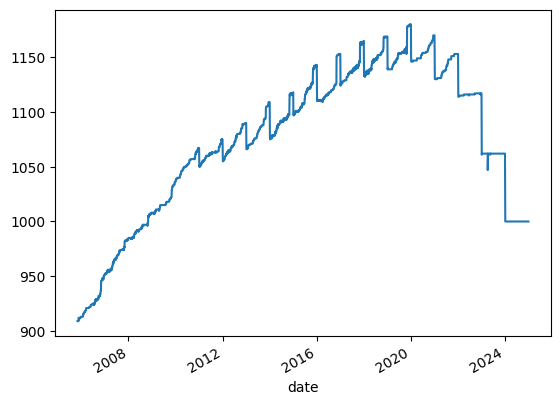

In [11]:
df[df['market_cap'].notna()].groupby('date').size().plot()

## Split to yearly universe data: previous 3 year + universe year

In [13]:
def get_monthly_factor_mining_data(
    df: pd.DataFrame,
    target_year: int,
    target_month: int,
    symbol_col: str = "instrument_id",
    time_col: str = "date",
    pool_dict: dict = None,
    lookback_months: int = 37,
) -> pd.DataFrame:

    if target_month < 1 or target_month > 12:
        raise ValueError("target_month 必須介於 1 到 12")

    if target_year not in pool_dict:
        raise ValueError(f"pool_dict 中找不到 target_year={target_year}")

    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col])
    out = out.sort_values([symbol_col, time_col]).reset_index(drop=True)

    target_month_start = pd.Timestamp(year=target_year, month=target_month, day=1)
    start_month = target_month_start - pd.DateOffset(months=lookback_months)

    out = out[
        (out[time_col] >= start_month) &
        (out[time_col] <= pd.Timestamp(year=target_year, month=12, day=31)) &
        (out[symbol_col].isin(pool_dict[target_year]))
    ].reset_index(drop=True)

    
    return out



In [14]:
all_dfs = []

for y in range(OOS_START_YEAR, CUT_OUT_YEAR+1):
    df_tem = get_monthly_factor_mining_data(
        df=df,
        target_year=y,
        target_month=1,
        pool_dict=eligible_dict,
        lookback_months=36
    )
    all_dfs.append(df_tem)


## Fill Market cap with CS median

In [15]:
def fill_market_cap_by_cross_section_median(
    all_dfs: list[pd.DataFrame],
    date_col: str = "date",
    value_col: str = "market_cap",
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    For each dataframe in all_dfs:
    - identify dates with missing market_cap
    - fill missing market_cap by same-date cross-sectional median
    - return filled dataframes and missing-value report
    """

    filled_dfs = []
    report_rows = []

    for k, df in enumerate(all_dfs):
        out = df.copy()
        out[date_col] = pd.to_datetime(out[date_col])

        # before filling: missing count by date
        daily_missing = (
            out.groupby(date_col)[value_col]
            .agg(
                n_total="size",
                n_missing=lambda x: x.isna().sum(),
                n_available=lambda x: x.notna().sum(),
                cs_median="median",
            )
            .reset_index()
        )

        daily_missing["df_id"] = k
        daily_missing["has_missing"] = daily_missing["n_missing"] > 0

        report_rows.append(daily_missing)

        # same-date cross-sectional median
        cs_median_by_date = out.groupby(date_col)[value_col].transform("median")

        # fill missing market_cap with same-date median
        out[value_col] = out[value_col].fillna(cs_median_by_date)

        # safety check: if an entire date is missing, median is NaN and cannot be filled
        remaining_missing = out[value_col].isna().sum()
        if remaining_missing > 0:
            print(
                f"[Warning] dataframe {k}: still has {remaining_missing} missing "
                f"{value_col}. This means some dates have all values missing."
            )

        filled_dfs.append(out)

    missing_report = pd.concat(report_rows, ignore_index=True)

    return filled_dfs, missing_report

all_dfs, market_cap_missing_report = fill_market_cap_by_cross_section_median(
    all_dfs=all_dfs,
    date_col="date",
    value_col="market_cap",
)

## Feature Confirmation in Yearly Universe 
- For every CS in the previous 3 year, I want the NaN value of a feature < 50%
- If NaN > 50% for any CS in previous year, drop that feature

In [16]:
import pandas as pd
import numpy as np


def filter_features_by_training_year_missingness_fast(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    feature_groups: dict[str, list[str]],
    date_col: str = "date",
    missing_threshold: float = 0.50,
) -> tuple[list[pd.DataFrame], dict[int, list[str]], pd.DataFrame, pd.DataFrame]:

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    candidate_cols = [
        col
        for group_cols in feature_groups.values()
        for col in group_cols
    ]
    candidate_cols = list(dict.fromkeys(candidate_cols))

    all_dfs_filtered = []
    valid_feature_cols_by_year = {}
    dropped_rows = []
    daily_report_list = []

    for df_raw, universe_year in zip(all_dfs, universe_years):
        df = df_raw.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        train_year = universe_year - 1

        train_df = df.loc[df[date_col] < pd.to_datetime(f'{universe_year}-01-01')].copy()

        if train_df.empty:
            raise ValueError(
                f"Universe year {universe_year}: no training-year data found for {train_year}."
            )

        check_cols = [c for c in candidate_cols if c in df.columns]

        # 一次性計算每日總筆數
        n_total_by_date = train_df.groupby(date_col).size()

        # 一次性計算所有 feature 每日 missing 數
        missing_counts = (
            train_df
            .groupby(date_col)[check_cols]
            .apply(lambda x: x.isna().sum())
        )

        # daily missing fraction: index=date, columns=features
        missing_frac = missing_counts.div(n_total_by_date, axis=0)

        # 每個 feature 的最大 daily missing fraction
        max_missing_frac = missing_frac.max(axis=0)

        # 是否要刪除
        dropped_cols = max_missing_frac[
            max_missing_frac > missing_threshold
        ].index.tolist()

        valid_cols = [
            c for c in check_cols
            if c not in dropped_cols
        ]

        # 建 dropped report
        for col in dropped_cols:
            worst_date = missing_frac[col].idxmax()
            n_total = int(n_total_by_date.loc[worst_date])
            n_missing = int(missing_counts.loc[worst_date, col])

            dropped_rows.append({
                "universe_year": universe_year,
                "train_year": train_year,
                "feature": col,
                "max_missing_frac": float(missing_frac.loc[worst_date, col]),
                "worst_date": worst_date,
                "n_total_on_worst_date": n_total,
                "n_missing_on_worst_date": n_missing,
                "n_available_on_worst_date": n_total - n_missing,
                "reason": f"daily missing fraction > {missing_threshold:.0%} in training year",
            })

        # 建 daily report，長表格式
        daily_report = (
            missing_frac
            .reset_index()
            .melt(
                id_vars=date_col,
                var_name="feature",
                value_name="missing_frac",
            )
        )
        daily_report["universe_year"] = universe_year
        daily_report["train_year"] = train_year

        daily_report_list.append(daily_report)

        # 從整個 previous-year + current-year df 刪掉 bad features
        df_filtered = df.drop(columns=dropped_cols, errors="ignore")

        all_dfs_filtered.append(df_filtered)
        valid_feature_cols_by_year[universe_year] = valid_cols

        print(
            f"Universe year {universe_year}: "
            f"checked {len(check_cols)} features, "
            f"kept {len(valid_cols)}, "
            f"dropped {len(dropped_cols)}."
        )

    dropped_feature_report = pd.DataFrame(dropped_rows)

    daily_missing_report = (
        pd.concat(daily_report_list, ignore_index=True)
        if daily_report_list
        else pd.DataFrame()
    )

    return (
        all_dfs_filtered,
        valid_feature_cols_by_year,
        dropped_feature_report,
        daily_missing_report,
    )

In [17]:
all_dfs_filtered, valid_feature_cols_by_year, dropped_feature_report, daily_missing_report = (
    filter_features_by_training_year_missingness_fast(
        all_dfs=all_dfs,
        universe_years=universe_years,
        feature_groups=feature_groups,
        date_col="date",
        missing_threshold=0.50,
    )
)

Universe year 2019: checked 87 features, kept 87, dropped 0.
Universe year 2020: checked 87 features, kept 87, dropped 0.
Universe year 2021: checked 87 features, kept 87, dropped 0.
Universe year 2022: checked 87 features, kept 87, dropped 0.
Universe year 2023: checked 87 features, kept 87, dropped 0.
Universe year 2024: checked 87 features, kept 87, dropped 0.


In [18]:
import json
from pathlib import Path

Path("processed").mkdir(parents=True, exist_ok=True)

# JSON 的 key 會自動變成 string，所以先轉成 str 比較清楚
valid_feature_cols_by_year_json = {
    str(year): cols
    for year, cols in valid_feature_cols_by_year.items()
}

with open("processed/valid_feature_cols_by_year.json", "w") as f:
    json.dump(valid_feature_cols_by_year_json, f, indent=4)

# Cut off Extreme Values
Using 5 MAD

In [19]:
import numpy as np
import pandas as pd


def median_mad_winsorize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> pd.DataFrame:
    """
    Cross-sectional median-MAD winsorization by date.

    For each date t and feature x:
        median_t = median_i(x_{i,t})
        mad_t    = median_i(|x_{i,t} - median_t|)
        lower_t  = median_t - n_mad * mad_t
        upper_t  = median_t + n_mad * mad_t

    Then clip each x_{i,t} into [lower_t, upper_t].

    If mad_t == 0 or NaN, the feature-date is left unchanged.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    # Ensure numeric
    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    # Cross-sectional median by date
    cs_median = out.groupby(date_col)[cols].transform("median")

    # Cross-sectional MAD by date
    abs_dev = (out[cols] - cs_median).abs()
    cs_mad = abs_dev.groupby(out[date_col]).transform("median")

    lower = cs_median - n_mad * cs_mad
    upper = cs_median + n_mad * cs_mad

    # If MAD is 0 or NaN, do not clip that feature-date
    valid_mad = cs_mad.notna() & (cs_mad != 0)

    clipped = out[cols].clip(lower=lower, upper=upper, axis=0)

    out[cols] = out[cols].where(~valid_mad, clipped)

    return out

In [20]:
def winsorize_all_dfs_by_year(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional median-MAD winsorization to each yearly dataframe.

    Each dataframe uses that year's valid feature columns only.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs):
        cols = valid_feature_cols_by_year[year]
        cols = [c for c in cols if c in df_year.columns]

        df_w = median_mad_winsorize_cross_section_fast(
            df=df_year,
            cols=cols,
            date_col=date_col,
            n_mad=n_mad,
        )

        out_dfs.append(df_w)

        print(
            f"Universe year {year}: winsorized {len(cols)} features "
            f"with {n_mad} MAD threshold."
        )

    return out_dfs

In [21]:
all_dfs_winsor = winsorize_all_dfs_by_year(
    all_dfs=all_dfs,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    n_mad=5.0,
)

Universe year 2019: winsorized 87 features with 5.0 MAD threshold.
Universe year 2020: winsorized 87 features with 5.0 MAD threshold.
Universe year 2021: winsorized 87 features with 5.0 MAD threshold.
Universe year 2022: winsorized 87 features with 5.0 MAD threshold.
Universe year 2023: winsorized 87 features with 5.0 MAD threshold.
Universe year 2024: winsorized 87 features with 5.0 MAD threshold.


In [22]:
def summarize_winsorization_changes(
    all_dfs_before: list[pd.DataFrame],
    all_dfs_after: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
) -> pd.DataFrame:
    rows = []

    for year, before, after in zip(universe_years, all_dfs_before, all_dfs_after):
        cols = [c for c in valid_feature_cols_by_year[year] if c in before.columns and c in after.columns]

        for col in cols:
            b = before[col]
            a = after[col]

            changed = b.notna() & a.notna() & (b != a)

            rows.append({
                "universe_year": year,
                "feature": col,
                "n_changed": int(changed.sum()),
                "changed_frac": float(changed.mean()),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["universe_year", "changed_frac"], ascending=[True, False])
        .reset_index(drop=True)
    )
winsor_change_report = summarize_winsorization_changes(
    all_dfs_before=all_dfs,
    all_dfs_after=all_dfs_winsor,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
)

display(winsor_change_report.head(30))

,universe_year,feature,n_changed,changed_frac
0,2019,LINEARREG_SLOPE_volume_5,157083,0.157505
1,2019,LINEARREG_SLOPE_volume_20,154597,0.155012
2,2019,estimate_turnover,126643,0.126983
3,2019,deps,125817,0.126155
4,2019,MIDPOINT_volume_20,124070,0.124403
5,2019,DEMA_volume_5,122607,0.122936
6,2019,MIDPOINT_volume_5,122603,0.122932
7,2019,DEMA_volume_20,120297,0.120620
8,2019,KAMA_volume_5,119241,0.119561
9,2019,KAMA_volume_20,116184,0.116496


# Impute features by industry CS median

In [24]:
def impute_features_by_industry_median_cross_section_with_report(
    df: pd.DataFrame,
    feature_cols: list[str],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Same-date same-industry median imputation with detailed report.

    Imputation hierarchy:
    1. same-date same-industry median
    2. same-date market median
    3. fallback_value
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if id_col not in out.columns:
        raise ValueError(f"{id_col} not found in df.")
    if industry_col not in out.columns:
        raise ValueError(f"{industry_col} not found in df.")

    feature_cols = [c for c in feature_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")

    original_missing = out[feature_cols].isna()

    # -----------------------------
    # Same-date same-industry median
    # -----------------------------
    industry_median = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("median")
    )

    industry_available_count = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Same-date market median fallback
    # -----------------------------
    market_median = (
        out.groupby(date_col)[feature_cols]
        .transform("median")
    )

    market_available_count = (
        out.groupby(date_col)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Decide imputation method
    # -----------------------------
    used_industry = original_missing & industry_median.notna()
    used_market = original_missing & industry_median.isna() & market_median.notna()
    used_fallback = original_missing & industry_median.isna() & market_median.isna()

    # -----------------------------
    # Fill values
    # -----------------------------
    out[feature_cols] = (
        out[feature_cols]
        .fillna(industry_median)
        .fillna(market_median)
        .fillna(fallback_value)
    )

    # -----------------------------
    # Build detailed long report
    # -----------------------------
    base_cols = [id_col, date_col, industry_col]

    report_frames = []

    for method_name, method_mask, value_source, n_ind_source, n_market_source in [
        (
            "industry_median",
            used_industry,
            industry_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "market_median",
            used_market,
            market_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "fallback_value",
            used_fallback,
            pd.DataFrame(
                fallback_value,
                index=out.index,
                columns=feature_cols,
            ),
            industry_available_count,
            market_available_count,
        ),
    ]:
        if not method_mask.to_numpy().any():
            continue

        mask_long = (
            method_mask
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="was_imputed_by_method",
            )
        )

        mask_long = mask_long.loc[mask_long["was_imputed_by_method"]].copy()

        if mask_long.empty:
            continue

        value_long = (
            value_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="imputed_value",
            )
        )

        n_ind_long = (
            n_ind_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_same_industry",
            )
        )

        n_market_long = (
            n_market_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_market",
            )
        )

        meta = out[base_cols].reset_index()

        temp_report = (
            mask_long[["index", "feature"]]
            .merge(meta, on="index", how="left")
            .merge(value_long, on=["index", "feature"], how="left")
            .merge(n_ind_long, on=["index", "feature"], how="left")
            .merge(n_market_long, on=["index", "feature"], how="left")
        )

        temp_report["impute_method"] = method_name

        report_frames.append(temp_report)

    if report_frames:
        impute_report = pd.concat(report_frames, ignore_index=True)
        impute_report = impute_report[
            [
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        ].sort_values([date_col, "feature", id_col])
    else:
        impute_report = pd.DataFrame(
            columns=[
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        )

    return out, impute_report

In [25]:
def impute_all_dfs_by_industry_median_with_report(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    Apply same-date same-industry median imputation to every yearly dataframe.
    Also return a detailed imputation report.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []
    report_list = []

    for year, df_year in zip(universe_years, all_dfs):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_imputed, impute_report_year = (
            impute_features_by_industry_median_cross_section_with_report(
                df=df_year,
                feature_cols=feature_cols,
                date_col=date_col,
                id_col=id_col,
                industry_col=industry_col,
                fallback_value=fallback_value,
            )
        )

        impute_report_year["universe_year"] = year

        n_missing_after = df_imputed[feature_cols].isna().sum().sum()
        n_imputed = len(impute_report_year)

        print(
            f"Universe year {year}: imputed {len(feature_cols)} features. "
            f"Total imputed cells = {n_imputed}. "
            f"Remaining missing = {n_missing_after}."
        )

        out_dfs.append(df_imputed)
        report_list.append(impute_report_year)

    impute_report = (
        pd.concat(report_list, ignore_index=True)
        if report_list
        else pd.DataFrame()
    )

    return out_dfs, impute_report

In [26]:
all_dfs_imputed, impute_report = impute_all_dfs_by_industry_median_with_report(
    all_dfs=all_dfs,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    id_col="instrument_id",
    industry_col="gics_industry",
    fallback_value=0.0,
)

Universe year 2019: imputed 87 features. Total imputed cells = 652917. Remaining missing = 0.
Universe year 2020: imputed 87 features. Total imputed cells = 612784. Remaining missing = 0.
Universe year 2021: imputed 87 features. Total imputed cells = 567071. Remaining missing = 0.
Universe year 2022: imputed 87 features. Total imputed cells = 509717. Remaining missing = 0.
Universe year 2023: imputed 87 features. Total imputed cells = 414253. Remaining missing = 0.
Universe year 2024: imputed 87 features. Total imputed cells = 354272. Remaining missing = 0.


In [28]:
impute_summary_by_year = (
    impute_report
    .groupby(["universe_year", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
)

display(impute_summary_by_year)

,universe_year,impute_method,n_imputed_cells
0,2019,industry_median,652917
1,2020,industry_median,612784
2,2021,industry_median,567071
3,2022,industry_median,506291
4,2022,market_median,3426
5,2023,industry_median,410806
6,2023,market_median,3447
7,2024,industry_median,350825
8,2024,market_median,3447


In [29]:
impute_summary_by_feature = (
    impute_report
    .groupby(["universe_year", "feature", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
    .sort_values(["universe_year", "n_imputed_cells"], ascending=[True, False])
)

display(impute_summary_by_feature.head(50))

,universe_year,feature,impute_method,n_imputed_cells
74,2019,repsf4,industry_median,49655
75,2019,repsfl,industry_median,45148
65,2019,inesn,industry_median,40595
66,2019,inesp,industry_median,40595
72,2019,reps1,industry_median,34942
73,2019,reps41,industry_median,31657
61,2019,epsp,industry_median,31621
80,2019,sue,industry_median,31147
60,2019,epsf,industry_median,30030
76,2019,repsfs,industry_median,30030


# Neutralization
- Typically, we expect that Log(Market Cap) and Industry has predictability
- We want to keep a feature's unexplained part, which is the OLS residual
- OLS: Feature = alpha + beta_1 * log(market cap) + beta_industry * industry_dummy_variable + residual
- Since there are no NaNs in Market cap or Industry, we can use the OLS to fill NaN

In [30]:
def neutralize_cross_section_multioutput_ols(
    df: pd.DataFrame,
    feature_cols: list[str],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
    min_obs_buffer: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cross-sectional multi-output OLS neutralization.

    For each date:
        Y = X B + E

    Y contains all feature columns together.
    X contains intercept, continuous controls, and categorical dummies.
    Feature columns are replaced by residuals.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if continuous_cols is None:
        continuous_cols = []

    if categorical_cols is None:
        categorical_cols = []

    if add_log_market_cap:
        if market_cap_col not in out.columns:
            raise ValueError(f"{market_cap_col} not found in df.")

        out["log_market_cap"] = np.log(
            pd.to_numeric(out[market_cap_col], errors="coerce")
        )

        if "log_market_cap" not in continuous_cols:
            continuous_cols = ["log_market_cap"] + continuous_cols

    feature_cols = [c for c in feature_cols if c in out.columns]
    continuous_cols = [c for c in continuous_cols if c in out.columns]
    categorical_cols = [c for c in categorical_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")
    out[continuous_cols] = out[continuous_cols].apply(pd.to_numeric, errors="coerce")

    result_parts = []
    beta_records = []

    for dt, g in out.groupby(date_col, sort=True):
        g = g.copy()

        X_parts = [
            pd.DataFrame(
                {"intercept": np.ones(len(g), dtype=float)},
                index=g.index,
            )
        ]

        if continuous_cols:
            X_parts.append(g[continuous_cols].astype(float))

        if categorical_cols:
            cat_parts = []

            for cat_col in categorical_cols:
                dummies = pd.get_dummies(
                    g[cat_col].astype("category"),
                    prefix=cat_col,
                    drop_first=True,
                    dtype=float,
                )
                cat_parts.append(dummies)

            if cat_parts:
                X_parts.append(pd.concat(cat_parts, axis=1))

        X_df = pd.concat(X_parts, axis=1)
        x_names = X_df.columns.tolist()

        valid_x = X_df.notna().all(axis=1)

        X = X_df.loc[valid_x].to_numpy(dtype=float)
        Y = g.loc[valid_x, feature_cols].to_numpy(dtype=float)

        n_obs = X.shape[0]
        n_regressors = X.shape[1]
        min_obs = n_regressors + min_obs_buffer

        if n_obs < min_obs:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "FALLBACK",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "insufficient observations; demean fallback",
            })

            result_parts.append(g)
            continue

        try:
            B, *_ = np.linalg.lstsq(X, Y, rcond=None)

            Y_hat = X @ B
            Y_resid = Y - Y_hat

            g.loc[valid_x, feature_cols] = Y_resid

            if (~valid_x).any():
                g.loc[~valid_x, feature_cols] = 0.0

            # beta_df: long format
            for j, x_col in enumerate(x_names):
                for k, feature in enumerate(feature_cols):
                    beta_records.append({
                        date_col: pd.Timestamp(dt),
                        "feature": feature,
                        "x_col": x_col,
                        "beta": float(B[j, k]),
                        "n_obs": n_obs,
                        "n_total": len(g),
                        "note": "",
                    })

        except np.linalg.LinAlgError:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "LINALG_ERROR",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "lstsq failed; demean fallback",
            })

        result_parts.append(g)

    out_neu = pd.concat(result_parts, axis=0).sort_index()
    beta_df = pd.DataFrame(beta_records)

    return out_neu, beta_df

In [31]:
def neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
) -> tuple[list[pd.DataFrame], dict[int, pd.DataFrame]]:
    """
    Apply cross-sectional multi-output OLS neutralization to every yearly dataframe.
    """

    if len(all_dfs_imputed) != len(universe_years):
        raise ValueError("len(all_dfs_imputed) must equal len(universe_years).")

    out_dfs = []
    beta_by_year = {}

    for year, df_year in zip(universe_years, all_dfs_imputed):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_neu, beta_df = neutralize_cross_section_multioutput_ols(
            df=df_year,
            feature_cols=feature_cols,
            continuous_cols=continuous_cols,
            categorical_cols=categorical_cols,
            date_col=date_col,
            market_cap_col=market_cap_col,
            add_log_market_cap=add_log_market_cap,
        )

        n_missing = df_neu[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: neutralized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

        out_dfs.append(df_neu)
        beta_by_year[year] = beta_df

    return out_dfs, beta_by_year

In [32]:
all_dfs_neu, beta_by_year = neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed=all_dfs_imputed,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    continuous_cols=["log_market_cap"],
    categorical_cols=["gics_industry"],
    date_col="date",
    market_cap_col="market_cap",
    add_log_market_cap=True,
)

Universe year 2019: neutralized 87 features. Remaining missing = 0.
Universe year 2020: neutralized 87 features. Remaining missing = 0.
Universe year 2021: neutralized 87 features. Remaining missing = 0.
Universe year 2022: neutralized 87 features. Remaining missing = 0.
Universe year 2023: neutralized 87 features. Remaining missing = 0.
Universe year 2024: neutralized 87 features. Remaining missing = 0.


In [ ]:
# from pathlib import Path
# import json
# import pandas as pd

# save_dir = Path("processed/all_dfs_neu")
# save_dir.mkdir(parents=True, exist_ok=True)

# universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

# for year, df_year in zip(universe_years, all_dfs_neu):
#     path = save_dir / f"universe_{year}_neutralized.parquet"
#     df_year.to_parquet(path, index=False)
#     print(f"Saved {year}: {path}, shape={df_year.shape}")

# metadata = {
#     "universe_years": universe_years,
#     "description": "Neutralized and imputed yearly universe dataframes",
# }

# with open(save_dir / "metadata.json", "w") as f:
#     json.dump(metadata, f, indent=4)

Saved 2019: processed/all_dfs_neu/universe_2019_neutralized.parquet, shape=(997322, 93)
Saved 2020: processed/all_dfs_neu/universe_2020_neutralized.parquet, shape=(998188, 93)
Saved 2021: processed/all_dfs_neu/universe_2021_neutralized.parquet, shape=(998300, 93)
Saved 2022: processed/all_dfs_neu/universe_2022_neutralized.parquet, shape=(996981, 93)
Saved 2023: processed/all_dfs_neu/universe_2023_neutralized.parquet, shape=(996175, 93)
Saved 2024: processed/all_dfs_neu/universe_2024_neutralized.parquet, shape=(999022, 93)


In [34]:
from pathlib import Path
import json
import pandas as pd
import json

with open("processed/valid_feature_cols_by_year.json", "r") as f:
    valid_feature_cols_by_year_loaded = json.load(f)

# 把 key 轉回 int
valid_feature_cols_by_year_loaded = {
    int(year): cols
    for year, cols in valid_feature_cols_by_year_loaded.items()
}
save_dir = Path("processed/all_dfs_neu")

with open(save_dir / "metadata.json", "r") as f:
    metadata = json.load(f)


universe_years = metadata["universe_years"]

all_dfs_neu = []

for year in universe_years:
    path = save_dir / f"universe_{year}_neutralized.parquet"
    df_year = pd.read_parquet(path)
    df_year["date"] = pd.to_datetime(df_year["date"])
    all_dfs_neu.append(df_year)

    print(f"Loaded {year}: shape={df_year.shape}")

Loaded 2019: shape=(997322, 93)
Loaded 2020: shape=(998188, 93)
Loaded 2021: shape=(998300, 93)
Loaded 2022: shape=(996981, 93)
Loaded 2023: shape=(996175, 93)
Loaded 2024: shape=(999022, 93)


# Standarization

In [35]:
def zscore_standardize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> pd.DataFrame:
    """
    Cross-sectional z-score standardization by date.

    For each date t and feature k:
        z_{i,t,k} = (x_{i,t,k} - mean_{t,k}) / std_{t,k}

    If std is 0 or NaN:
        - fill_zero_if_constant=True: set z-score to 0
        - otherwise: set z-score to NaN

    This function is vectorized across columns.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    cs_mean = out.groupby(date_col)[cols].transform("mean")
    cs_std = out.groupby(date_col)[cols].transform(lambda x: x.std(ddof=ddof))

    z = (out[cols] - cs_mean) / cs_std

    invalid_std = cs_std.isna() | (cs_std == 0)

    if fill_zero_if_constant:
        z = z.mask(invalid_std, 0.0)
    else:
        z = z.mask(invalid_std, np.nan)

    out[cols] = z

    return out

In [36]:
def zscore_all_dfs_by_year(
    all_dfs_neu: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional z-score standardization to every yearly universe dataframe.

    Each year's dataframe uses only that year's valid features.
    """

    if len(all_dfs_neu) != len(universe_years):
        raise ValueError("len(all_dfs_neu) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs_neu):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_z = zscore_standardize_cross_section_fast(
            df=df_year,
            cols=feature_cols,
            date_col=date_col,
            ddof=ddof,
            fill_zero_if_constant=fill_zero_if_constant,
        )

        out_dfs.append(df_z)

        n_missing = df_z[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: standardized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

    return out_dfs

In [37]:
all_dfs_z = zscore_all_dfs_by_year(
    all_dfs_neu=all_dfs_neu,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    ddof=0,
    fill_zero_if_constant=True,
)

Universe year 2019: standardized 87 features. Remaining missing = 0.
Universe year 2020: standardized 87 features. Remaining missing = 0.
Universe year 2021: standardized 87 features. Remaining missing = 0.
Universe year 2022: standardized 87 features. Remaining missing = 0.
Universe year 2023: standardized 87 features. Remaining missing = 0.
Universe year 2024: standardized 87 features. Remaining missing = 0.


In [ ]:
# from pathlib import Path
# import json
# import pandas as pd

# save_dir = Path("processed/all_dfs_z")
# save_dir.mkdir(parents=True, exist_ok=True)

# universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

# for year, df_year in zip(universe_years, all_dfs_z):
#     path = save_dir / f"universe_{year}_z.parquet"
#     df_year.to_parquet(path, index=False)
#     print(f"Saved {year}: {path}, shape={df_year.shape}")

# metadata = {
#     "universe_years": universe_years,
#     "description": "Neutralized and imputed yearly universe dataframes",
# }

# with open(save_dir / "metadata.json", "w") as f:
#     json.dump(metadata, f, indent=4)

Saved 2019: processed/all_dfs_z/universe_2019_z.parquet, shape=(997322, 93)
Saved 2020: processed/all_dfs_z/universe_2020_z.parquet, shape=(998188, 93)
Saved 2021: processed/all_dfs_z/universe_2021_z.parquet, shape=(998300, 93)
Saved 2022: processed/all_dfs_z/universe_2022_z.parquet, shape=(996981, 93)
Saved 2023: processed/all_dfs_z/universe_2023_z.parquet, shape=(996175, 93)
Saved 2024: processed/all_dfs_z/universe_2024_z.parquet, shape=(999022, 93)


In [39]:
from pathlib import Path
import json
import pandas as pd

save_dir = Path("processed/all_dfs_z")

with open(save_dir / "metadata.json", "r") as f:
    metadata = json.load(f)


universe_years = metadata["universe_years"]

all_dfs_z = []

for year in universe_years:
    path = save_dir / f"universe_{year}_z.parquet"
    df_year = pd.read_parquet(path)
    df_year["date"] = pd.to_datetime(df_year["date"])
    all_dfs_z.append(df_year)

    print(f"Loaded {year}: shape={df_year.shape}")





Loaded 2019: shape=(997322, 93)
Loaded 2020: shape=(998188, 93)
Loaded 2021: shape=(998300, 93)
Loaded 2022: shape=(996981, 93)
Loaded 2023: shape=(996175, 93)
Loaded 2024: shape=(999022, 93)


In [40]:
def check_zscore_by_year(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
) -> pd.DataFrame:
    rows = []

    for year, df_year in zip(universe_years, all_dfs_z):
        df = df_year.copy()
        df[date_col] = pd.to_datetime(df[date_col])

        cols = [c for c in valid_feature_cols_by_year[year] if c in df.columns]

        daily_mean = df.groupby(date_col)[cols].mean()
        daily_std = df.groupby(date_col)[cols].std(ddof=0)

        rows.append({
            "universe_year": year,
            "max_abs_daily_mean": daily_mean.abs().max().max(),
            "median_daily_std": daily_std.median().median(),
            "min_daily_std": daily_std.min().min(),
            "max_daily_std": daily_std.max().max(),
            "n_missing": df[cols].isna().sum().sum(),
        })

    return pd.DataFrame(rows)


zscore_check = check_zscore_by_year(
    all_dfs_z=all_dfs_z,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
)

display(zscore_check)

,universe_year,max_abs_daily_mean,median_daily_std,min_daily_std,max_daily_std,n_missing
0,2019,4.529710e-17,1.0,1.0,1.0,0
1,2020,5.187749e-17,1.0,1.0,1.0,0
2,2021,4.840572e-17,1.0,1.0,1.0,0
3,2022,4.263256e-17,1.0,1.0,1.0,0
4,2023,4.606735e-17,1.0,1.0,1.0,0
5,2024,4.751755e-17,1.0,1.0,1.0,0


## Merge with SP500 return

In [ ]:
all_dfs_z = [
    df.assign(date=pd.to_datetime(df["date"])).merge(
        sp500,
        on="date",
        how="left",
        validate="m:1",
    )
    for df in all_dfs_z
]

# Section 5
# Model Pipeline

**For each prediction month:**

past 12 months  

→ first 10 months: label top/bottom \(n\%\) returns and train classifier  

→ validation 2 months: predict scores  

→ use validation no-cost portfolio return / Sharpe / IC / ICIR to select hyperparameters  

→ refit on full 12 months using top/bottom \(n\%\) labels  

→ predict next month  

→ output `predictions_*` with model scores  

→ formal backtest with eligibility filters, trading costs, slippage, and borrow costs  

In [41]:
import numpy as np
import pandas as pd

from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
from sklearn.linear_model import ElasticNet

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt



from sklearn.model_selection import ParameterGrid
from sklearn.base import clone


## Generate Label

In [42]:
def make_cross_section_extreme_labels(
    df: pd.DataFrame,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    label_pct: float = 0.30,
    out_col: str = "target_label",
) -> pd.DataFrame:
    """
    For each date:
        top label_pct by target return -> +1
        bottom label_pct by target return -> -1
        middle -> 0

    Training later uses only +1 and -1.
    """

    if not (0 < label_pct < 0.5):
        raise ValueError("label_pct must be between 0 and 0.5.")

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out[target_col] = pd.to_numeric(out[target_col], errors="coerce")

    out[out_col] = 0

    valid = out[target_col].notna()

    # Rank return within each date.
    # rank_pct_high close to 1 = high return.
    rank_pct_high = (
        out.loc[valid]
        .groupby(date_col)[target_col]
        .rank(method="first", pct=True, ascending=True)
    )

    out.loc[valid & (rank_pct_high >= 1.0 - label_pct), out_col] = 1
    out.loc[valid & (rank_pct_high <= label_pct), out_col] = -1

    return out

## Get Classifier Score

In [43]:
def get_classifier_score(
    model,
    X: np.ndarray,
    positive_class: int = 1,
    negative_class: int = -1,
) -> np.ndarray:
    """
    Convert classifier output into a continuous score.

    Preferred:
        score = P(y=+1) - P(y=-1)

    Fallback:
        decision_function or predict.
    """

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        classes = list(model.classes_)

        score = np.zeros(X.shape[0], dtype=float)

        if positive_class in classes:
            pos_idx = classes.index(positive_class)
            score += proba[:, pos_idx]

        if negative_class in classes:
            neg_idx = classes.index(negative_class)
            score -= proba[:, neg_idx]

        return score

    if hasattr(model, "decision_function"):
        score = model.decision_function(X)

        if np.ndim(score) == 2:
            classes = list(model.classes_)
            out = np.zeros(X.shape[0], dtype=float)

            if positive_class in classes:
                out += score[:, classes.index(positive_class)]

            if negative_class in classes:
                out -= score[:, classes.index(negative_class)]

            return out

        return score.astype(float)

    return model.predict(X).astype(float)

## Build Return from Scores

In [44]:
def build_no_cost_daily_return_from_scores(
    df: pd.DataFrame,
    score_col: str = "score",
    return_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.10,
    min_names: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build no-cost daily long-short returns from model scores.

    For each date:
        top trade_pct by score -> long
        bottom trade_pct by score -> short

    Return:
        long_return = mean(raw return of long names)
        short_return = mean(-raw return of short names)
        portfolio_return = 0.5 * long_return + 0.5 * short_return
    """

    if not (0 < trade_pct < 0.5):
        raise ValueError("trade_pct must be between 0 and 0.5.")

    temp = df[[date_col, id_col, score_col, return_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp[score_col] = pd.to_numeric(temp[score_col], errors="coerce")
    temp[return_col] = pd.to_numeric(temp[return_col], errors="coerce")

    temp = temp.dropna(subset=[score_col, return_col]).copy()

    if temp.empty:
        return pd.DataFrame(), pd.DataFrame()

    temp["n_names"] = temp.groupby(date_col)[id_col].transform("count")
    temp = temp.loc[temp["n_names"] >= min_names].copy()

    if temp.empty:
        return pd.DataFrame(), pd.DataFrame()

    rank_high = temp.groupby(date_col)[score_col].rank(method="first", pct=True, ascending=True)

    temp["side"] = 0
    temp.loc[rank_high >= 1.0 - trade_pct, "side"] = 1
    temp.loc[rank_high <= trade_pct, "side"] = -1

    position_df = temp.loc[temp["side"].ne(0)].copy()

    position_df["stock_return_gross"] = np.where(
        position_df["side"].eq(1),
        position_df[return_col],
        -position_df[return_col],
    )

    long_daily = (
        position_df.loc[position_df["side"].eq(1)]
        .groupby(date_col)
        .agg(
            long_return=("stock_return_gross", "mean"),
            n_long_actual=(id_col, "count"),
        )
    )

    short_daily = (
        position_df.loc[position_df["side"].eq(-1)]
        .groupby(date_col)
        .agg(
            short_return=("stock_return_gross", "mean"),
            n_short_actual=(id_col, "count"),
        )
    )

    daily_return_df = (
        long_daily
        .join(short_daily, how="inner")
        .sort_index()
        .reset_index()
    )

    daily_return_df["portfolio_return"] = (
        0.5 * daily_return_df["long_return"]
        + 0.5 * daily_return_df["short_return"]
    )

    daily_return_df["cum_return_simple"] = daily_return_df["portfolio_return"].fillna(0.0).cumsum()

    return daily_return_df, position_df

## Validation Metrics 
return / sharpe / ic / icir

In [262]:
def summarize_daily_return(
    daily_return_df: pd.DataFrame,
    return_col: str = "portfolio_return",
    periods_per_year: int = 252,
) -> dict:
    r = pd.to_numeric(daily_return_df[return_col], errors="coerce").dropna()

    if r.empty:
        return {
            "mean_daily_return": np.nan,
            "total_return_simple": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe": np.nan,
            "n_return_days": 0,
        }

    ann_return = r.mean() * periods_per_year
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = np.nan
    if pd.notna(ann_vol) and ann_vol != 0:
        sharpe = ann_return / ann_vol

    return {
        "mean_daily_return": r.mean(),
        "total_return_simple": r.sum(),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "n_return_days": len(r),
    }


def evaluate_validation_scores(
    val_eval: pd.DataFrame,
    score_col: str = "score",
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.10,
    min_ic_names: int = 30,
    periods_per_year: int = 252,
) -> dict:
    """
    Evaluate model score on validation set by:
    1. no-cost long-short return
    2. daily Spearman IC
    """

    daily_ret, position_df = build_no_cost_daily_return_from_scores(
        df=val_eval,
        score_col=score_col,
        return_col=target_col,
        date_col=date_col,
        id_col=id_col,
        trade_pct=trade_pct,
        min_names=min_ic_names,
    )

    ret_summary = summarize_daily_return(
        daily_return_df=daily_ret,
        return_col="portfolio_return",
        periods_per_year=periods_per_year,
    )

    ic = daily_spearman_ic_fast(
        df=val_eval,
        score_col=score_col,
        target_col=target_col,
        date_col=date_col,
        min_names=min_ic_names,
    )

    ic_summary = summarize_ic(ic)

    icir = np.nan
    if pd.notna(ic_summary["ic_std"]) and ic_summary["ic_std"] != 0:
        icir = ic_summary["ic_mean"] / ic_summary["ic_std"]

    out = {
        "val_mean_daily_return": ret_summary["mean_daily_return"],
        "val_total_return_simple": ret_summary["total_return_simple"],
        "val_annualized_return": ret_summary["annualized_return"],
        "val_annualized_volatility": ret_summary["annualized_volatility"],
        "val_sharpe": ret_summary["sharpe"],
        "val_n_return_days": ret_summary["n_return_days"],
        "val_ic_mean": ic_summary["ic_mean"],
        "val_ic_std": ic_summary["ic_std"],
        "val_ic_tstat": ic_summary["ic_tstat"],
        "val_icir": icir,
        "val_n_ic_days": ic_summary["n_days"],
    }

    return out


def get_selection_score(
    metrics: dict,
    selection_metric: str = "sharpe",
) -> float:
    """
    selection_metric can be:
        'return'  -> validation total simple return
        'abs_return' -> absolute validation total simple return
        'sharpe'  -> validation Sharpe
        'ic'      -> validation mean IC
        'icir'    -> validation ICIR
    """

    if selection_metric == "return":
        return metrics.get("val_total_return_simple", np.nan)

    if selection_metric == "abs_return":
        x = metrics.get("val_total_return_simple", np.nan)
        return abs(x) if pd.notna(x) else np.nan

    if selection_metric == "sharpe":
        return metrics.get("val_sharpe", np.nan)

    if selection_metric == "ic":
        return metrics.get("val_ic_mean", np.nan)

    if selection_metric == "icir":
        return metrics.get("val_icir", np.nan)

    raise ValueError(
        "selection_metric must be one of: "
        "'return', 'abs_return', 'sharpe', 'ic', 'icir'."
    )

## Generic classifier one-window framework

In [259]:
def fit_select_refit_predict_classifier_one_window(
    df_window: pd.DataFrame,
    df_predict: pd.DataFrame,
    feature_cols: list[str],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    label_col: str = "target_label",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_month: int = 36,
    val_month: int = 6,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
    min_train_obs: int = 500,
    min_val_obs: int = 200,
    min_ic_names: int = 30,
    periods_per_year: int = 252,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generic classification rolling-window framework.

    Optional first step:
    1. Label the full train+validation window.
    2. Train a simple model on the training portion.
    3. Compute permutation importance on labelled validation samples.
    4. Remove features with negative permutation importance.

    Then run the normal workflow:
    1. Train candidate models on the training window.
    2. Select hyperparameters by validation Sharpe / IC metric.
    3. Refit best model on the full train+validation window.
    4. Predict the next prediction window.
    """

    from sklearn.inspection import permutation_importance

    df_window = df_window.copy()
    df_predict = df_predict.copy()

    df_window[date_col] = pd.to_datetime(df_window[date_col])
    df_predict[date_col] = pd.to_datetime(df_predict[date_col])

    if eligibility_col is not None and eligibility_col in df_window.columns:
        df_window = df_window.loc[df_window[eligibility_col].astype(bool)].copy()

    if eligibility_col is not None and eligibility_col in df_predict.columns:
        df_predict = df_predict.loc[df_predict[eligibility_col].astype(bool)].copy()

    if df_window.empty or df_predict.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Drop last training-window date to avoid target availability leakage.
    last_window_date = df_window[date_col].max()
    df_window = df_window.loc[df_window[date_col] < last_window_date].copy()

    if df_window.empty:
        return pd.DataFrame(), pd.DataFrame()

    feature_cols = [
        c for c in feature_cols
        if c in df_window.columns and c in df_predict.columns
    ]

    if not feature_cols:
        return pd.DataFrame(), pd.DataFrame()

    df_window = df_window.dropna(subset=feature_cols + [target_col_raw]).copy()
    df_predict = df_predict.dropna(subset=feature_cols).copy()

    if df_window.empty or df_predict.empty:
        return pd.DataFrame(), pd.DataFrame()

    if val_month <= 0 or whole_train_month <= val_month:
        raise ValueError("whole_train_month must be greater than val_month, and val_month must be positive.")

    train_month = whole_train_month - val_month
    window_start = df_window[date_col].min().normalize()
    val_start = window_start + pd.DateOffset(months=train_month)

    train_df = df_window.loc[df_window[date_col] < val_start].copy()
    val_df = df_window.loc[df_window[date_col] >= val_start].copy()

    if len(train_df) < min_train_obs or len(val_df) < min_val_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_data",
            "n_train_raw": len(train_df),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_month": whole_train_month,
            "train_month": train_month,
            "val_month": val_month,
            "n_features_before_filter": len(feature_cols),
            "n_features_after_filter": len(feature_cols),
            "permutation_filter_used": use_permutation_feature_filter,
        }])
        return pd.DataFrame(), diagnostics

    # Label the full train+validation window so the permutation step can use labelled validation rows.
    labelled_window = make_cross_section_extreme_labels(
        df=df_window,
        target_col=target_col_raw,
        date_col=date_col,
        label_pct=label_pct,
        out_col=label_col,
    )

    train_df = labelled_window.loc[labelled_window[date_col] < val_start].copy()
    val_df = labelled_window.loc[labelled_window[date_col] >= val_start].copy()

    train_labeled = train_df.loc[train_df[label_col].isin([-1, 1])].copy()
    val_labeled_for_filter = val_df.loc[val_df[label_col].isin([-1, 1])].copy()

    if len(train_labeled) < min_train_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_labelled_train_data",
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_month": whole_train_month,
            "train_month": train_month,
            "val_month": val_month,
            "n_features_before_filter": len(feature_cols),
            "n_features_after_filter": len(feature_cols),
            "permutation_filter_used": use_permutation_feature_filter,
        }])
        return pd.DataFrame(), diagnostics

    feature_cols_before_filter = feature_cols.copy()
    permutation_filter_status = "not_used"
    permutation_removed_features = []
    permutation_importance_table = pd.DataFrame()

    if use_permutation_feature_filter:
        filter_factory = permutation_filter_model_factory or model_factory
        filter_params = permutation_filter_params or {}

        filter_train = train_labeled.dropna(subset=feature_cols + [label_col]).copy()
        filter_val = val_labeled_for_filter.dropna(subset=feature_cols + [label_col]).copy()

        if len(filter_train) < min_train_obs or len(filter_val) < min_val_obs:
            permutation_filter_status = "skipped_insufficient_labelled_validation_data"
        else:
            try:
                basic_model = filter_factory(filter_params)
                basic_model.fit(
                    filter_train[feature_cols].to_numpy(dtype=float),
                    filter_train[label_col].to_numpy(dtype=int),
                )

                perm = permutation_importance(
                    estimator=basic_model,
                    X=filter_val[feature_cols].to_numpy(dtype=float),
                    y=filter_val[label_col].to_numpy(dtype=int),
                    scoring=permutation_filter_scoring,
                    n_repeats=permutation_filter_n_repeats,
                    random_state=permutation_filter_random_state,
                    n_jobs=1,
                )

                permutation_importance_table = pd.DataFrame({
                    "feature": feature_cols,
                    "permutation_importance_mean": perm.importances_mean,
                    "permutation_importance_std": perm.importances_std,
                }).sort_values("permutation_importance_mean", ascending=False)

                kept_features = permutation_importance_table.loc[
                    permutation_importance_table["permutation_importance_mean"] >= 0,
                    "feature",
                ].tolist()

                permutation_removed_features = permutation_importance_table.loc[
                    permutation_importance_table["permutation_importance_mean"] < 0,
                    "feature",
                ].tolist()

                if len(kept_features) == 0:
                    kept_features = (
                        permutation_importance_table
                        .head(max(1, min(permutation_filter_min_features, len(permutation_importance_table))))
                        ["feature"]
                        .tolist()
                    )
                    permutation_filter_status = "fallback_kept_top_features"
                else:
                    permutation_filter_status = "ok"

                feature_cols = kept_features

            except Exception as e:
                permutation_filter_status = f"failed: {e}"

    if use_permutation_feature_filter:
        print(
            f"{model_name} {df_predict[date_col].min():%Y-%m}: "
            f"permutation filter status={permutation_filter_status}; "
            f"kept {len(feature_cols)} / {len(feature_cols_before_filter)} features; "
            f"removed {len(permutation_removed_features)}."
        )

    train_labeled = train_labeled.dropna(subset=feature_cols + [label_col]).copy()
    val_df = val_df.dropna(subset=feature_cols + [target_col_raw]).copy()

    if len(train_labeled) < min_train_obs or len(val_df) < min_val_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_data_after_feature_filter",
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_month": whole_train_month,
            "train_month": train_month,
            "val_month": val_month,
            "n_features_before_filter": len(feature_cols_before_filter),
            "n_features_after_filter": len(feature_cols),
            "n_features_removed_by_permutation": len(permutation_removed_features),
            "permutation_filter_used": use_permutation_feature_filter,
            "permutation_filter_status": permutation_filter_status,
        }])
        return pd.DataFrame(), diagnostics

    X_train = train_labeled[feature_cols].to_numpy(dtype=float)
    y_train = train_labeled[label_col].to_numpy(dtype=int)

    X_val = val_df[feature_cols].to_numpy(dtype=float)

    best_score = -np.inf
    best_params = None
    diag_rows = []

    for params in ParameterGrid(param_grid):
        model = model_factory(params)

        try:
            model.fit(X_train, y_train)
            val_score = get_classifier_score(model, X_val)
        except Exception as e:
            diag_rows.append({
                "model_name": model_name,
                "status": "fit_failed",
                "params": params,
                "error": str(e),
                "selection_metric": selection_metric,
                "selection_score": np.nan,
                "n_train_labeled": len(train_labeled),
                "n_val": len(val_df),
                "n_features": len(feature_cols),
                "n_features_before_filter": len(feature_cols_before_filter),
                "n_features_after_filter": len(feature_cols),
                "n_features_removed_by_permutation": len(permutation_removed_features),
                "permutation_filter_used": use_permutation_feature_filter,
                "permutation_filter_status": permutation_filter_status,
            })
            continue

        val_eval = val_df[[id_col, date_col, target_col_raw]].copy()
        val_eval["score"] = val_score

        metrics = evaluate_validation_scores(
            val_eval=val_eval,
            score_col="score",
            target_col=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            trade_pct=trade_pct,
            min_ic_names=min_ic_names,
            periods_per_year=periods_per_year,
        )

        selection_score = get_selection_score(
            metrics=metrics,
            selection_metric=selection_metric,
        )

        row = {
            "model_name": model_name,
            "status": "ok",
            "params": params,
            "selection_metric": selection_metric,
            "selection_score": selection_score,
            "label_pct": label_pct,
            "trade_pct": trade_pct,
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "n_features": len(feature_cols),
            "whole_train_month": whole_train_month,
            "train_month": train_month,
            "val_month": val_month,
            "n_features_before_filter": len(feature_cols_before_filter),
            "n_features_after_filter": len(feature_cols),
            "n_features_removed_by_permutation": len(permutation_removed_features),
            "permutation_filter_used": use_permutation_feature_filter,
            "permutation_filter_status": permutation_filter_status,
            "removed_features_by_permutation": str(permutation_removed_features),
        }

        row.update(metrics)
        diag_rows.append(row)

        if pd.notna(selection_score) and selection_score > best_score:
            best_score = selection_score
            best_params = params

    diagnostics = pd.DataFrame(diag_rows)

    if best_params is None:
        return pd.DataFrame(), diagnostics

    diagnostics["is_best"] = diagnostics["params"].astype(str).eq(str(best_params))

    full_labeled = labelled_window.loc[labelled_window[label_col].isin([-1, 1])].copy()
    full_labeled = full_labeled.dropna(subset=feature_cols + [label_col]).copy()

    X_full = full_labeled[feature_cols].to_numpy(dtype=float)
    y_full = full_labeled[label_col].to_numpy(dtype=int)

    final_model = model_factory(best_params)
    final_model.fit(X_full, y_full)

    pred_df = df_predict.dropna(subset=feature_cols).copy()
    X_pred = pred_df[feature_cols].to_numpy(dtype=float)

    pred_out = pred_df[[id_col, date_col]].copy()

    if target_col_raw in pred_df.columns:
        pred_out[target_col_raw] = pred_df[target_col_raw].values

    pred_out["model_name"] = model_name
    pred_out["score"] = get_classifier_score(final_model, X_pred)
    pred_out["best_params"] = str(best_params)
    pred_out["selection_metric"] = selection_metric
    pred_out["label_pct"] = label_pct
    pred_out["trade_pct"] = trade_pct
    pred_out["train_window_start"] = df_window[date_col].min()
    pred_out["train_window_end_exclusive"] = last_window_date
    pred_out["prediction_month"] = pred_out[date_col].dt.to_period("M").astype(str)
    pred_out["whole_train_month"] = whole_train_month
    pred_out["train_month"] = train_month
    pred_out["val_month"] = val_month
    pred_out["n_features_before_filter"] = len(feature_cols_before_filter)
    pred_out["n_features_after_filter"] = len(feature_cols)
    pred_out["n_features_removed_by_permutation"] = len(permutation_removed_features)
    pred_out["permutation_filter_used"] = use_permutation_feature_filter
    pred_out["permutation_filter_status"] = permutation_filter_status

    diagnostics["best_params"] = str(best_params)
    diagnostics["train_window_start"] = df_window[date_col].min()
    diagnostics["train_window_end_exclusive"] = last_window_date
    diagnostics["prediction_month"] = (
        pred_out["prediction_month"].iloc[0] if len(pred_out) else None
    )
    diagnostics["whole_train_month"] = whole_train_month
    diagnostics["train_month"] = train_month
    diagnostics["val_month"] = val_month

    return pred_out, diagnostics


## One universe / all universes runner

In [260]:
def run_classifier_monthly_walk_forward_one_universe(
    df_year: pd.DataFrame,
    universe_year: int,
    feature_cols: list[str],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_month: int = 36,
    val_month: int = 6,
    predict_month: int = 1,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df = df_year.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([date_col, id_col]).reset_index(drop=True)

    if predict_month <= 0:
        raise ValueError("predict_month must be positive.")

    prediction_months = pd.period_range(
        start=f"{universe_year}-01",
        end=f"{universe_year}-12",
        freq="M",
    )[::predict_month]
    universe_end = pd.Timestamp(year=universe_year + 1, month=1, day=1)

    all_predictions = []
    all_diagnostics = []

    for pred_month in prediction_months:
        pred_start = pred_month.to_timestamp()
        pred_end = min(pred_start + pd.DateOffset(months=predict_month), universe_end)

        trainval_start = pred_start - pd.DateOffset(months=whole_train_month)
        trainval_end = pred_start

        df_window = df.loc[
            (df[date_col] >= trainval_start)
            & (df[date_col] < trainval_end)
        ].copy()

        df_predict = df.loc[
            (df[date_col] >= pred_start)
            & (df[date_col] < pred_end)
        ].copy()

        if df_window.empty or df_predict.empty:
            continue

        pred_out, diag = fit_select_refit_predict_classifier_one_window(
            df_window=df_window,
            df_predict=df_predict,
            feature_cols=feature_cols,
            model_factory=model_factory,
            param_grid=param_grid,
            model_name=model_name,
            label_pct=label_pct,
            trade_pct=trade_pct,
            selection_metric=selection_metric,
            target_col_raw=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            whole_train_month=whole_train_month,
            val_month=val_month,
            use_permutation_feature_filter=use_permutation_feature_filter,
            permutation_filter_model_factory=permutation_filter_model_factory,
            permutation_filter_params=permutation_filter_params,
            permutation_filter_scoring=permutation_filter_scoring,
            permutation_filter_n_repeats=permutation_filter_n_repeats,
            permutation_filter_random_state=permutation_filter_random_state,
            permutation_filter_min_features=permutation_filter_min_features,
        )

        if not pred_out.empty:
            pred_out["universe_year"] = universe_year
            all_predictions.append(pred_out)

        if not diag.empty:
            diag["universe_year"] = universe_year
            diag["prediction_month"] = str(pred_month)
            diag["prediction_window_start"] = pred_start
            diag["prediction_window_end_exclusive"] = pred_end
            diag["predict_month"] = predict_month
            all_diagnostics.append(diag)

        print(
            f"Universe {universe_year}, predict {pred_month}: done. "
            f"Trainval = {trainval_start.date()} to {trainval_end.date()}. "
            f"Train months = {whole_train_month - val_month}, val months = {val_month}, "
            f"predict months = {predict_month}. "
            f"Permutation filter = {use_permutation_feature_filter}."
        )

    predictions = (
        pd.concat(all_predictions, ignore_index=True)
        if all_predictions
        else pd.DataFrame()
    )

    diagnostics = (
        pd.concat(all_diagnostics, ignore_index=True)
        if all_diagnostics
        else pd.DataFrame()
    )

    return predictions, diagnostics


def run_classifier_monthly_walk_forward_all_universes(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_month: int = 36,
    val_month: int = 6,
    predict_month: int = 1,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    if len(all_dfs_z) != len(universe_years):
        raise ValueError("len(all_dfs_z) must equal len(universe_years).")

    all_predictions = []
    all_diagnostics = []

    for df_year, year in zip(all_dfs_z, universe_years):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        pred, diag = run_classifier_monthly_walk_forward_one_universe(
            df_year=df_year,
            universe_year=year,
            feature_cols=feature_cols,
            model_factory=model_factory,
            param_grid=param_grid,
            model_name=model_name,
            label_pct=label_pct,
            trade_pct=trade_pct,
            selection_metric=selection_metric,
            target_col_raw=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            whole_train_month=whole_train_month,
            val_month=val_month,
            predict_month=predict_month,
            use_permutation_feature_filter=use_permutation_feature_filter,
            permutation_filter_model_factory=permutation_filter_model_factory,
            permutation_filter_params=permutation_filter_params,
            permutation_filter_scoring=permutation_filter_scoring,
            permutation_filter_n_repeats=permutation_filter_n_repeats,
            permutation_filter_random_state=permutation_filter_random_state,
            permutation_filter_min_features=permutation_filter_min_features,
        )

        if not pred.empty:
            all_predictions.append(pred)

        if not diag.empty:
            all_diagnostics.append(diag)

    predictions = (
        pd.concat(all_predictions, ignore_index=True)
        if all_predictions
        else pd.DataFrame()
    )

    diagnostics = (
        pd.concat(all_diagnostics, ignore_index=True)
        if all_diagnostics
        else pd.DataFrame()
    )

    return predictions, diagnostics


## IC

In [261]:
def daily_spearman_ic_fast(
    df: pd.DataFrame,
    score_col: str,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.Series:
    """
    Vectorized daily cross-sectional Spearman IC.

    Spearman IC = Pearson correlation between cross-sectional ranks.
    """

    temp = df[[date_col, score_col, target_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp[score_col] = pd.to_numeric(temp[score_col], errors="coerce")
    temp[target_col] = pd.to_numeric(temp[target_col], errors="coerce")

    temp = temp.dropna(subset=[score_col, target_col]).copy()

    if temp.empty:
        return pd.Series(dtype=float)

    temp["_score_rank"] = temp.groupby(date_col)[score_col].rank(method="average")
    temp["_target_rank"] = temp.groupby(date_col)[target_col].rank(method="average")

    temp["_score_dm"] = (
        temp["_score_rank"]
        - temp.groupby(date_col)["_score_rank"].transform("mean")
    )

    temp["_target_dm"] = (
        temp["_target_rank"]
        - temp.groupby(date_col)["_target_rank"].transform("mean")
    )

    temp["_cross"] = temp["_score_dm"] * temp["_target_dm"]
    temp["_score_sq"] = temp["_score_dm"] ** 2
    temp["_target_sq"] = temp["_target_dm"] ** 2

    agg = (
        temp.groupby(date_col)
        .agg(
            n_names=(score_col, "size"),
            cov_num=("_cross", "sum"),
            score_var=("_score_sq", "sum"),
            target_var=("_target_sq", "sum"),
        )
    )

    denom = np.sqrt(agg["score_var"] * agg["target_var"])

    ic = agg["cov_num"] / denom
    ic = ic.where(agg["n_names"] >= min_names)
    ic = ic.where(denom > 0)

    return ic.dropna()


def summarize_ic(ic: pd.Series) -> dict:
    if ic.empty:
        return {
            "ic_mean": np.nan,
            "ic_std": np.nan,
            "ic_tstat": np.nan,
            "n_days": 0,
        }

    ic_mean = ic.mean()
    ic_std = ic.std(ddof=1)
    n_days = len(ic)

    if pd.isna(ic_std) or ic_std == 0:
        ic_tstat = np.nan
    else:
        ic_tstat = ic_mean / ic_std * np.sqrt(n_days)

    return {
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "ic_tstat": ic_tstat,
        "n_days": n_days,
    }

## Target winsorized

In [50]:
def make_cs_winsorized_zscore_target(
    df: pd.DataFrame,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    n_mad: float = 5.0,
    out_col: str = "target_cs_z",
) -> pd.DataFrame:
    """
    For each date:
    1. Cross-sectional median-MAD winsorize target.
    2. Cross-sectional z-score target.

    The processed target is only used for model training.
    Raw target_col should still be used for IC / PnL evaluation.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    y = pd.to_numeric(out[target_col], errors="coerce")

    cs_median = y.groupby(out[date_col]).transform("median")

    abs_dev = (y - cs_median).abs()
    cs_mad = abs_dev.groupby(out[date_col]).transform("median")

    lower = cs_median - n_mad * cs_mad
    upper = cs_median + n_mad * cs_mad

    valid_mad = cs_mad.notna() & (cs_mad != 0)

    y_win = y.copy()
    y_win = y_win.where(~valid_mad, y.clip(lower=lower, upper=upper))

    cs_mean = y_win.groupby(out[date_col]).transform("mean")
    cs_std = y_win.groupby(out[date_col]).transform(lambda x: x.std(ddof=0))

    y_z = (y_win - cs_mean) / cs_std
    y_z = y_z.replace([np.inf, -np.inf], np.nan)
    y_z = y_z.where(cs_std.notna() & (cs_std != 0), np.nan)

    out[out_col] = y_z

    return out

## Compute Train IC

In [264]:
def compute_train_feature_ic_table(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "target_cs_z",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.DataFrame:
    """
    Compute daily single-feature Spearman IC on the training set,
    then summarize mean IC for each feature.
    """

    records = []

    for feature in feature_cols:
        temp = train_df[[date_col, feature, target_col]].copy()
        temp = temp.rename(columns={feature: "feature_value", target_col: "target"})

        ic = daily_spearman_ic_fast(
            df=temp,
            score_col="feature_value",
            target_col="target",
            date_col=date_col,
            min_names=min_names,
        )

        if ic.empty:
            records.append({
                "feature": feature,
                "ic_mean": np.nan,
                "ic_abs_mean": np.nan,
                "ic_tstat": np.nan,
                "n_days": 0,
            })
            continue

        ic_summary = summarize_ic(ic)

        records.append({
            "feature": feature,
            "ic_mean": ic_summary["ic_mean"],
            "ic_abs_mean": abs(ic_summary["ic_mean"]),
            "ic_tstat": ic_summary["ic_tstat"],
            "n_days": ic_summary["n_days"],
        })

    ic_table = pd.DataFrame(records)

    ic_table = (
        ic_table
        .sort_values("ic_abs_mean", ascending=False)
        .reset_index(drop=True)
    )

    return ic_table

In [280]:
# Rolling-window configuration.
# whole_train_month=36 and val_month=6 means first 30 months are used for model selection training,
# the last 6 months are used for validation, then the best model is refit on all 36 months.
whole_train_month = 6
val_month = 2
predict_month = 1


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


def make_rf_classifier(params: dict) -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=params.get("n_estimators", 300),
        max_depth=params.get("max_depth", 5),
        min_samples_leaf=params.get("min_samples_leaf", 50),
        max_features=params.get("max_features", "sqrt"),
        bootstrap=params.get("bootstrap", True),
        class_weight=params.get("class_weight", "balanced_subsample"),
        n_jobs=params.get("n_jobs", -1),
        random_state=params.get("random_state", 42),
    )


rf_classifier_param_grid = {
    "n_estimators": [100],
    "max_depth": [1, 2],
    "min_samples_leaf": [100],
    "max_features": ['sqrt', 0.2],
    "bootstrap": [True],
    "class_weight": ["balanced_subsample"],
    "n_jobs": [-1],
    "random_state": [2026],
}

# Basic RF used only for the initial permutation feature filter.
rf_permutation_filter_params = {
    "n_estimators": 50,
    "max_depth": 2,
    "min_samples_leaf": 100,
    "max_features": "sqrt",
    "bootstrap": True,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": 2026,
}

predictions_rf_cls, diagnostics_rf_cls = run_classifier_monthly_walk_forward_all_universes(
    all_dfs_z=all_dfs_z[-1:],
    universe_years=universe_years[-1:],
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    model_factory=make_rf_classifier,
    param_grid=rf_classifier_param_grid,
    model_name="rf_classifier_top_bottom",
    label_pct=0.30,
    trade_pct=0.499,
    selection_metric="sharpe",
    target_col_raw="target_c2o_next_adj",
    date_col="date",
    id_col="instrument_id",
    eligibility_col="is_eligible",
    whole_train_month=whole_train_month,
    val_month=val_month,
    predict_month=predict_month,
    use_permutation_feature_filter=True,
    permutation_filter_model_factory=make_rf_classifier,
    permutation_filter_params=rf_permutation_filter_params,
    permutation_filter_scoring="balanced_accuracy",
    permutation_filter_n_repeats=3,
    permutation_filter_random_state=2026,
    permutation_filter_min_features=5,
)

In [ ]:
predictions_rf_cls.to_csv('prediction/predictions_rf_cls.csv')
diagnostics_rf_cls.to_csv('prediction/diagnostics_rf_cls.csv')

## 5-3 IC mean, t-statistic, stability across years and across regimes

In [278]:
def summarize_ic_by_group(
    ic_df: pd.DataFrame,
    group_col: str,
    ic_col: str = "ic",
) -> pd.DataFrame:
    rows = []

    for group_value, g in ic_df.groupby(group_col):
        ic = pd.to_numeric(g[ic_col], errors="coerce").dropna()

        if ic.empty:
            rows.append({
                group_col: group_value,
                "ic_mean": np.nan,
                "ic_std": np.nan,
                "ic_tstat": np.nan,
                "n_days": 0,
            })
            continue

        ic_mean = ic.mean()
        ic_std = ic.std(ddof=1)
        n_days = len(ic)

        ic_tstat = np.nan
        if pd.notna(ic_std) and ic_std != 0:
            ic_tstat = ic_mean / ic_std * np.sqrt(n_days)

        rows.append({
            group_col: group_value,
            "ic_mean": ic_mean,
            "ic_std": ic_std,
            "ic_tstat": ic_tstat,
            "n_days": n_days,
        })

    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


# -----------------------------
# 1. Daily cross-sectional IC
# -----------------------------
rf_ic_input = predictions_rf_cls.copy()
rf_ic_input["date"] = pd.to_datetime(rf_ic_input["date"])

rf_daily_ic = (
    daily_spearman_ic_fast(
        df=rf_ic_input,
        score_col="score",
        target_col="target_c2o_next_adj",
        date_col="date",
        min_names=30,
    )
    .rename("ic")
    .reset_index()
)

rf_daily_ic["date"] = pd.to_datetime(rf_daily_ic["date"])
rf_daily_ic["year"] = rf_daily_ic["date"].dt.year

overall_ic_summary = summarize_ic(rf_daily_ic["ic"])

rf_overall_ic_table = pd.DataFrame([{
    "model_name": "rf_classifier_top_bottom",
    "ic_mean": overall_ic_summary["ic_mean"],
    "ic_std": overall_ic_summary["ic_std"],
    "ic_tstat": overall_ic_summary["ic_tstat"],
    "n_days": overall_ic_summary["n_days"],
}])

display(rf_overall_ic_table)


# -----------------------------
# 2. IC stability across years
# -----------------------------
rf_yearly_ic_table = summarize_ic_by_group(
    ic_df=rf_daily_ic,
    group_col="year",
    ic_col="ic",
)

display(rf_yearly_ic_table)


# -----------------------------
# 3. Define simple market regimes
# -----------------------------
daily_market_return = (
    rf_ic_input
    .groupby("date")["target_c2o_next_adj"]
    .mean()
    .rename("equal_weight_market_return")
    .reset_index()
)

rf_daily_ic = rf_daily_ic.merge(
    daily_market_return,
    how="left",
    on="date",
    validate="1:1",
)

flat_threshold = rf_daily_ic["equal_weight_market_return"].abs().quantile(0.25)

rf_daily_ic["market_regime"] = np.select(
    [
        rf_daily_ic["equal_weight_market_return"] > flat_threshold,
        rf_daily_ic["equal_weight_market_return"] < -flat_threshold,
    ],
    [
        "up_market",
        "down_market",
    ],
    default="flat_market",
)

rf_regime_ic_table = summarize_ic_by_group(
    ic_df=rf_daily_ic,
    group_col="market_regime",
    ic_col="ic",
)

display(rf_regime_ic_table)


# -----------------------------
# 4. Optional combined year-regime stability table
# -----------------------------
rf_year_regime_ic_table = (
    rf_daily_ic
    .groupby(["year", "market_regime"])["ic"]
    .agg(
        ic_mean="mean",
        ic_std=lambda x: x.std(ddof=1),
        n_days="count",
    )
    .reset_index()
)

rf_year_regime_ic_table["ic_tstat"] = (
    rf_year_regime_ic_table["ic_mean"]
    / rf_year_regime_ic_table["ic_std"]
    * np.sqrt(rf_year_regime_ic_table["n_days"])
)

rf_year_regime_ic_table.loc[
    (rf_year_regime_ic_table["ic_std"].isna())
    | (rf_year_regime_ic_table["ic_std"].eq(0)),
    "ic_tstat"
] = np.nan

display(rf_year_regime_ic_table)




# 5. Save tables for report
Path("prediction").mkdir(parents=True, exist_ok=True)

rf_daily_ic.to_csv("prediction/rf_daily_ic.csv", index=False)
rf_overall_ic_table.to_csv("prediction/rf_overall_ic_table.csv", index=False)
rf_yearly_ic_table.to_csv("prediction/rf_yearly_ic_table.csv", index=False)
rf_regime_ic_table.to_csv("prediction/rf_regime_ic_table.csv", index=False)
rf_year_regime_ic_table.to_csv("prediction/rf_year_regime_ic_table.csv", index=False)

,model_name,ic_mean,ic_std,ic_tstat,n_days
0,rf_classifier_top_bottom,0.004835,0.08573,1.261021,500


,year,ic_mean,ic_std,ic_tstat,n_days
0,2023,0.009757,0.087227,1.768609,250
1,2024,-0.000087,0.084093,-0.016443,250


,market_regime,ic_mean,ic_std,ic_tstat,n_days
0,down_market,0.017314,0.084407,2.666564,169
1,flat_market,-0.001172,0.080251,-0.163269,125
2,up_market,-0.001758,0.089229,-0.282777,206


,year,market_regime,ic_mean,ic_std,n_days,ic_tstat
0,2023,down_market,0.003814,0.086880,100,0.438973
1,2023,flat_market,0.001231,0.084415,55,0.108114
2,2023,up_market,0.020949,0.088906,95,2.296632
3,2024,down_market,0.036878,0.077175,69,3.969342
4,2024,flat_market,-0.003060,0.077386,70,-0.330790
5,2024,up_market,-0.021192,0.085188,111,-2.620903


## 5-4 RF Feature Group Ablation

Train four leave-one-feature-group-out RF submodels. Each ablation uses the same walk-forward training logic as the full RF classifier: tune hyperparameters on the validation window, refit on the full train+validation window, and predict the next month. The only difference is that one feature group is removed from the candidate feature set.


In [242]:
from pathlib import Path

rf_ablation_feature_groups = feature_groups.copy()
rf_ablation_feature_universe = list(dict.fromkeys(
    col
    for group_cols in rf_ablation_feature_groups.values()
    for col in group_cols
))


def build_ablation_valid_feature_cols_by_year(
    valid_feature_cols_by_year: dict[int, list[str]],
    feature_groups: dict[str, list[str]],
    removed_group: str,
) -> dict[int, list[str]]:
    """Build yearly valid feature columns after removing one feature group."""
    removed_cols = set(feature_groups[removed_group])
    allowed_cols = set(
        col
        for group_name, group_cols in feature_groups.items()
        if group_name != removed_group
        for col in group_cols
    )

    out = {}

    for year, valid_cols in valid_feature_cols_by_year.items():
        out[year] = [
            col for col in valid_cols
            if col in allowed_cols and col not in removed_cols
        ]

    return out


def summarize_prediction_sharpe_by_model(
    predictions: pd.DataFrame,
    model_col: str = "model_name",
    score_col: str = "score",
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.20,
    min_names: int = 30,
) -> pd.DataFrame:
    """Summarize no-cost long-short Sharpe for each prediction set."""
    if predictions.empty:
        return pd.DataFrame()

    rows = []

    for model_name, g in predictions.groupby(model_col):
        daily_ret, _ = build_no_cost_daily_return_from_scores(
            df=g,
            score_col=score_col,
            return_col=target_col,
            date_col=date_col,
            id_col=id_col,
            trade_pct=trade_pct,
            min_names=min_names,
        )

        row = {
            model_col: model_name,
            "n_prediction_rows": len(g),
            "n_prediction_days": pd.to_datetime(g[date_col]).nunique(),
        }
        row.update(summarize_daily_return(daily_ret, return_col="portfolio_return"))
        rows.append(row)

    return pd.DataFrame(rows)


all_ablation_predictions = []
all_ablation_diagnostics = []
ablation_feature_count_rows = []

for removed_group in rf_ablation_feature_groups:
    print('==========================================================================')
    print(f'                     Removed Group: {removed_group}')
    print('==========================================================================')

    ablation_valid_feature_cols_by_year = build_ablation_valid_feature_cols_by_year(
        valid_feature_cols_by_year=valid_feature_cols_by_year,
        feature_groups=rf_ablation_feature_groups,
        removed_group=removed_group,
    )

    for year in universe_years:
        ablation_feature_count_rows.append({
            "removed_feature_group": removed_group,
            "universe_year": year,
            "n_features_used": len(ablation_valid_feature_cols_by_year.get(year, [])),
        })

    pred, diag = run_classifier_monthly_walk_forward_all_universes(
        all_dfs_z=all_dfs_z,
        universe_years=universe_years,
        valid_feature_cols_by_year=ablation_valid_feature_cols_by_year,
        model_factory=make_rf_classifier,
        param_grid=rf_classifier_param_grid,
        model_name=f"rf_without_{removed_group}",
        label_pct=0.20,
        trade_pct=0.20,
        selection_metric="sharpe",
        target_col_raw="target_c2o_next_adj",
        date_col="date",
        id_col="instrument_id",
        eligibility_col="is_eligible",
        whole_train_month=whole_train_month,
        val_month=val_month,
        predict_month=predict_month,
        use_permutation_feature_filter=True,
        permutation_filter_model_factory=make_rf_classifier,
        permutation_filter_params=rf_permutation_filter_params,
        permutation_filter_scoring="balanced_accuracy",
        permutation_filter_n_repeats=3,
        permutation_filter_random_state=2026,
        permutation_filter_min_features=5,
    )

    if not pred.empty:
        pred["removed_feature_group"] = removed_group
        all_ablation_predictions.append(pred)

    if not diag.empty:
        diag["removed_feature_group"] = removed_group
        all_ablation_diagnostics.append(diag)

predictions_rf_group_ablation = (
    pd.concat(all_ablation_predictions, ignore_index=True)
    if all_ablation_predictions
    else pd.DataFrame()
)

diagnostics_rf_group_ablation = (
    pd.concat(all_ablation_diagnostics, ignore_index=True)
    if all_ablation_diagnostics
    else pd.DataFrame()
)

rf_group_ablation_feature_counts = pd.DataFrame(ablation_feature_count_rows)

summary_rf_group_ablation = summarize_prediction_sharpe_by_model(
    predictions=predictions_rf_group_ablation,
    model_col="model_name",
    score_col="score",
    target_col="target_c2o_next_adj",
    date_col="date",
    id_col="instrument_id",
    trade_pct=0.20,
    min_names=30,
)

if not summary_rf_group_ablation.empty:
    summary_rf_group_ablation["removed_feature_group"] = (
        summary_rf_group_ablation["model_name"]
        .str.replace("rf_without_", "", regex=False)
    )

    if "predictions_rf_cls" in globals() and not predictions_rf_cls.empty:
        full_rf_summary = summarize_prediction_sharpe_by_model(
            predictions=predictions_rf_cls.assign(model_name="rf_full"),
            model_col="model_name",
            score_col="score",
            target_col="target_c2o_next_adj",
            date_col="date",
            id_col="instrument_id",
            trade_pct=0.20,
            min_names=30,
        )

        if not full_rf_summary.empty:
            full_rf_sharpe = full_rf_summary.loc[0, "sharpe"]
            full_rf_ann_return = full_rf_summary.loc[0, "annualized_return"]
            summary_rf_group_ablation["full_rf_sharpe"] = full_rf_sharpe
            summary_rf_group_ablation["full_rf_annualized_return"] = full_rf_ann_return
            summary_rf_group_ablation["sharpe_delta_vs_full_rf"] = (
                summary_rf_group_ablation["sharpe"] - full_rf_sharpe
            )
            summary_rf_group_ablation["annualized_return_delta_vs_full_rf"] = (
                summary_rf_group_ablation["annualized_return"] - full_rf_ann_return
            )

    summary_rf_group_ablation = (
        summary_rf_group_ablation
        .sort_values("sharpe", ascending=False)
        .reset_index(drop=True)
    )

Path("prediction").mkdir(parents=True, exist_ok=True)
predictions_rf_group_ablation.to_csv("prediction/predictions_rf_group_ablation.csv", index=False)
diagnostics_rf_group_ablation.to_csv("prediction/diagnostics_rf_group_ablation.csv", index=False)
summary_rf_group_ablation.to_csv("prediction/summary_rf_group_ablation.csv", index=False)
rf_group_ablation_feature_counts.to_csv("prediction/rf_group_ablation_feature_counts.csv", index=False)

print("RF leave-one-feature-group-out ablation summary:")
display(summary_rf_group_ablation)

print("Number of features used by ablation model and universe year:")
display(rf_group_ablation_feature_counts.head(20))


                     Removed Group: fundamental


KeyboardInterrupt: 

### 5-5 Identify at least two regimes or sub-periods where the IC is weak.
The model performs badly when the IC becomes weak or negative. The first weak area is the worst yearly IC period, shown in the yearly IC table. During this year, the model's ranking signal failed to line up with realized close-to-open returns. This likely happened because the six-month training window learned relationships that did not persist into the prediction month.

The second weak area is the weakest market regime, shown in the regime IC table. In this regime, returns are probably driven more by broad market moves, overnight news, and liquidity shocks than by stock-specific features. This makes cross-sectional ranking harder, especially for a model using mostly price-volume, fundamental, earnings, and short-interest features.

The rolling six-month IC table also shows that the model has unstable sub-periods. Therefore, the RF model should not be treated as uniformly predictive. A practical improvement would be to monitor rolling IC and reduce trading exposure when recent IC is weak.

# Section 6 
# Results

In [267]:
def build_long_short_daily_returns(
    signal_df: pd.DataFrame,
    n_long: int = 200,
    n_short: int = 200,
    date_col: str = "date",
    id_col: str = "instrument_id",
    score_col: str = "score",
    return_col: str = "target_c2o_next_adj",
    eligible_col: str = "is_eligible",
    total_trading_cost_bps_col: str = "slippage_commission_bps",
    commission_bps_col: str = "commission_bps",
    slippage_bps_col: str = "slippage_bps",
    borrow_rate_daily_col: str = "borrow_rate_daily",
    long_capital_weight: float = 0.5,
    short_capital_weight: float = 0.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build daily long-short portfolio returns with cost decomposition.

    Return streams:
    1. gross: no trading cost and no borrow cost
    2. after_commission: gross minus commission only
    3. after_slippage: gross minus commission and slippage
    4. net: gross minus commission, slippage, and borrow

    The staged return streams allow Sharpe degradation to be decomposed as:
        commission points = Sharpe(gross) - Sharpe(after_commission)
        slippage points   = Sharpe(after_commission) - Sharpe(after_slippage)
        borrow points     = Sharpe(after_slippage) - Sharpe(net)
    """

    df = signal_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    required_cols = [
        date_col,
        id_col,
        score_col,
        return_col,
        eligible_col,
        commission_bps_col,
        slippage_bps_col,
        borrow_rate_daily_col,
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df[return_col] = pd.to_numeric(df[return_col], errors="coerce")
    df[commission_bps_col] = pd.to_numeric(df[commission_bps_col], errors="coerce")
    df[slippage_bps_col] = pd.to_numeric(df[slippage_bps_col], errors="coerce")
    df[borrow_rate_daily_col] = pd.to_numeric(df[borrow_rate_daily_col], errors="coerce")

    df = df.loc[df[eligible_col].eq(True)].copy()

    df = df.dropna(
        subset=[
            date_col,
            id_col,
            score_col,
            return_col,
            commission_bps_col,
            slippage_bps_col,
            borrow_rate_daily_col,
        ]
    ).copy()

    # -----------------------------
    # Daily ranking among eligible stocks
    # -----------------------------
    df["rank_desc"] = (
        df.groupby(date_col)[score_col]
        .rank(method="first", ascending=False)
    )

    df["rank_asc"] = (
        df.groupby(date_col)[score_col]
        .rank(method="first", ascending=True)
    )

    df["side"] = 0

    df.loc[df["rank_desc"] <= n_long, "side"] = 1
    df.loc[df["rank_asc"] <= n_short, "side"] = -1

    position_df = df.loc[df["side"].ne(0)].copy()

    # -----------------------------
    # Cost components
    # -----------------------------
    position_df["commission_cost"] = position_df[commission_bps_col] / 10000.0
    position_df["slippage_cost"] = position_df[slippage_bps_col] / 10000.0

    position_df["borrow_cost"] = np.where(
        position_df["side"].eq(-1),
        position_df[borrow_rate_daily_col],
        0.0,
    )

    # Long gross return = raw return
    # Short gross return = -raw return
    position_df["stock_return_gross"] = np.where(
        position_df["side"].eq(1),
        position_df[return_col],
        -position_df[return_col],
    )

    position_df["stock_return_after_commission"] = (
        position_df["stock_return_gross"]
        - position_df["commission_cost"]
    )

    position_df["stock_return_after_slippage"] = (
        position_df["stock_return_after_commission"]
        - position_df["slippage_cost"]
    )

    position_df["stock_return_net"] = (
        position_df["stock_return_after_slippage"]
        - position_df["borrow_cost"]
    )

    # -----------------------------
    # Daily long / short book return
    # -----------------------------
    long_daily = (
        position_df.loc[position_df["side"].eq(1)]
        .groupby(date_col)
        .agg(
            long_return_gross=("stock_return_gross", "mean"),
            long_return_after_commission=("stock_return_after_commission", "mean"),
            long_return_after_slippage=("stock_return_after_slippage", "mean"),
            long_return_net=("stock_return_net", "mean"),
            n_long_actual=(id_col, "count"),
            long_avg_commission_cost=("commission_cost", "mean"),
            long_avg_slippage_cost=("slippage_cost", "mean"),
        )
    )

    short_daily = (
        position_df.loc[position_df["side"].eq(-1)]
        .groupby(date_col)
        .agg(
            short_return_gross=("stock_return_gross", "mean"),
            short_return_after_commission=("stock_return_after_commission", "mean"),
            short_return_after_slippage=("stock_return_after_slippage", "mean"),
            short_return_net=("stock_return_net", "mean"),
            n_short_actual=(id_col, "count"),
            short_avg_commission_cost=("commission_cost", "mean"),
            short_avg_slippage_cost=("slippage_cost", "mean"),
            short_avg_borrow_cost=("borrow_cost", "mean"),
        )
    )

    daily_return_df = (
        long_daily
        .join(short_daily, how="outer")
        .sort_index()
        .reset_index()
    )

    for stage in ["gross", "after_commission", "after_slippage", "net"]:
        daily_return_df[f"portfolio_return_{stage}"] = (
            long_capital_weight * daily_return_df[f"long_return_{stage}"]
            + short_capital_weight * daily_return_df[f"short_return_{stage}"]
        )

    daily_return_df["portfolio_commission_cost"] = (
        daily_return_df["portfolio_return_gross"]
        - daily_return_df["portfolio_return_after_commission"]
    )

    daily_return_df["portfolio_slippage_cost"] = (
        daily_return_df["portfolio_return_after_commission"]
        - daily_return_df["portfolio_return_after_slippage"]
    )

    daily_return_df["portfolio_borrow_cost"] = (
        daily_return_df["portfolio_return_after_slippage"]
        - daily_return_df["portfolio_return_net"]
    )

    daily_return_df["portfolio_trading_cost"] = (
        daily_return_df["portfolio_commission_cost"]
        + daily_return_df["portfolio_slippage_cost"]
    )

    for stage in ["gross", "after_commission", "after_slippage", "net"]:
        daily_return_df[f"cum_return_{stage}"] = (
            daily_return_df[f"portfolio_return_{stage}"].fillna(0.0)
        ).cumsum()

    return daily_return_df, position_df


In [268]:
def compute_performance_metrics(
    daily_return_df: pd.DataFrame,
    return_col: str = "portfolio_return_net",
    date_col: str = "date",
    periods_per_year: int = 252,
    use_simple_pnl: bool = True,
) -> pd.Series:
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    r = pd.to_numeric(df[return_col], errors="coerce").dropna()

    if r.empty:
        return pd.Series(dtype=float)

    n_days = len(r)

    if use_simple_pnl:
        equity = 1.0 + r.cumsum()
        total_return = r.sum()
        ann_return = r.mean() * periods_per_year
    else:
        equity = (1.0 + r).cumprod()
        total_return = equity.iloc[-1] - 1.0
        ann_return = equity.iloc[-1] ** (periods_per_year / n_days) - 1.0

    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = np.nan
    if pd.notna(ann_vol) and ann_vol != 0:
        sharpe = ann_return / ann_vol

    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_drawdown = drawdown.min()

    calmar = np.nan
    if pd.notna(max_drawdown) and max_drawdown != 0:
        calmar = ann_return / abs(max_drawdown)

    win_rate = (r > 0).mean()

    return pd.Series({
        "n_days": n_days,
        "total_return": total_return,
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "win_rate": win_rate,
        "avg_daily_return": r.mean(),
        "daily_volatility": r.std(ddof=1),
        "best_day": r.max(),
        "worst_day": r.min(),
        "pnl_convention": "simple_cumulative" if use_simple_pnl else "compounded",
    })

In [269]:
def plot_pnl(
    daily_return_df: pd.DataFrame,
    date_col: str = "date",
    save_path = None,
):
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    fig, ax = plt.subplots(figsize=(16, 7))

    ax.plot(
        df[date_col],
        df["cum_return_gross"],
        linewidth=2.0,
        label="Gross return",
    )

    ax.plot(
        df[date_col],
        df["cum_return_net"],
        linewidth=2.0,
        label="Net return",
    )

    ax.set_title("Long-Short Strategy Return", fontsize=16, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [270]:
def run_backtest_for_one_aum(
    predictions: pd.DataFrame,
    eligibility_df: pd.DataFrame,
    df_hardtoborrow: pd.DataFrame,
    aum_label: str,
    n_long: int = 100,
    n_short: int = 100,
    figure_dir: str = "figures",
    commission_bps: float = 1.0,
    total_trading_cost_bps_override = 4.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    For one AUM level:
    1. Merge model predictions with eligibility table.
    2. Merge borrow cost.
    3. Split total trading cost into commission and slippage.
    4. Build staged gross / after-commission / after-slippage / net returns.
    5. Compute performance metrics and Sharpe degradation by cost component.
    6. Plot PnL.

    If total_trading_cost_bps_override is not None, it is used as the total
    commission + slippage cost per leg. Otherwise, the function uses
    eligibility_df['slippage_commission_bps'].
    """

    from pathlib import Path

    Path(figure_dir).mkdir(parents=True, exist_ok=True)

    predict_cols = [
        "instrument_id",
        "date",
        "target_c2o_next_adj",
        "score",
    ]

    eligibility_cols = [
        "instrument_id",
        "date",
        "slippage_commission_bps",
        "is_eligible",
    ]

    borrow_cols = [
        "instrument_id",
        "date",
        "borrow_rate_daily",
    ]

    pred = predictions[predict_cols].copy()
    elig = eligibility_df[eligibility_cols].copy()
    borrow = df_hardtoborrow[borrow_cols].copy()

    pred["date"] = pd.to_datetime(pred["date"])
    elig["date"] = pd.to_datetime(elig["date"])
    borrow["date"] = pd.to_datetime(borrow["date"])

    pred["instrument_id"] = pred["instrument_id"].astype(int)
    elig["instrument_id"] = elig["instrument_id"].astype(int)
    borrow["instrument_id"] = borrow["instrument_id"].astype(int)

    signal_df = pred.merge(
        elig,
        how="left",
        on=["instrument_id", "date"],
        validate="m:1",
    )

    signal_df = signal_df.merge(
        borrow,
        how="left",
        on=["instrument_id", "date"],
        validate="m:1",
    )

    # Missing borrow is treated as a general-collateral borrow assumption: Tier A = 40 bps p.a.
    signal_df["borrow_rate_daily"] = (
        signal_df["borrow_rate_daily"]
        .fillna(0.004 / 252)
    )

    # If an eligibility row is missing, the stock cannot be traded.
    signal_df["is_eligible"] = signal_df["is_eligible"].fillna(False).astype(bool)

    if total_trading_cost_bps_override is None:
        signal_df["total_trading_cost_bps"] = pd.to_numeric(
            signal_df["slippage_commission_bps"],
            errors="coerce",
        )
    else:
        signal_df["total_trading_cost_bps"] = float(total_trading_cost_bps_override)

    signal_df["commission_bps"] = float(commission_bps)
    signal_df["slippage_bps"] = (
        signal_df["total_trading_cost_bps"]
        - signal_df["commission_bps"]
    ).clip(lower=0.0)

    daily_ret, position_df = build_long_short_daily_returns(
        signal_df=signal_df,
        n_long=n_long,
        n_short=n_short,
        date_col="date",
        id_col="instrument_id",
        score_col="score",
        return_col="target_c2o_next_adj",
        eligible_col="is_eligible",
        total_trading_cost_bps_col="total_trading_cost_bps",
        commission_bps_col="commission_bps",
        slippage_bps_col="slippage_bps",
        borrow_rate_daily_col="borrow_rate_daily",
    )

    metric_map = {
        "gross": "portfolio_return_gross",
        "after_commission": "portfolio_return_after_commission",
        "after_slippage": "portfolio_return_after_slippage",
        "net": "portfolio_return_net",
    }

    performance_table = pd.concat(
        [
            compute_performance_metrics(
                daily_return_df=daily_ret,
                return_col=return_col,
                date_col="date",
                periods_per_year=252,
            ).rename(stage)
            for stage, return_col in metric_map.items()
        ],
        axis=1,
    )

    performance_table["aum_label"] = aum_label
    performance_table["commission_bps"] = commission_bps
    performance_table["total_trading_cost_bps_override"] = total_trading_cost_bps_override

    sharpe_by_stage = performance_table.loc["sharpe"]
    degradation_table = pd.DataFrame([{
        "aum_label": aum_label,
        "gross_sharpe": sharpe_by_stage["gross"],
        "after_commission_sharpe": sharpe_by_stage["after_commission"],
        "after_slippage_sharpe": sharpe_by_stage["after_slippage"],
        "net_sharpe": sharpe_by_stage["net"],
        "commission_sharpe_points": sharpe_by_stage["gross"] - sharpe_by_stage["after_commission"],
        "slippage_sharpe_points": sharpe_by_stage["after_commission"] - sharpe_by_stage["after_slippage"],
        "borrow_sharpe_points": sharpe_by_stage["after_slippage"] - sharpe_by_stage["net"],
        "total_gross_to_net_sharpe_points": sharpe_by_stage["gross"] - sharpe_by_stage["net"],
        "avg_daily_commission_cost": daily_ret["portfolio_commission_cost"].mean(),
        "avg_daily_slippage_cost": daily_ret["portfolio_slippage_cost"].mean(),
        "avg_daily_borrow_cost": daily_ret["portfolio_borrow_cost"].mean(),
        "avg_daily_trading_cost": daily_ret["portfolio_trading_cost"].mean(),
        "commission_bps": commission_bps,
        "avg_slippage_bps": signal_df.loc[signal_df["is_eligible"], "slippage_bps"].mean(),
        "avg_total_trading_cost_bps": signal_df.loc[signal_df["is_eligible"], "total_trading_cost_bps"].mean(),
    }])

    plot_pnl(
        daily_return_df=daily_ret,
        date_col="date",
        save_path=f"{figure_dir}/rf_cls_{aum_label}_pnl.png",
    )

    return signal_df, daily_ret, performance_table, degradation_table


## 6-2 + 6-3
## Provide the headline performance table at 50M, 250M, and 1B portfolio-AUM
## Decompose the gross-to-net Sharpe degradation

This section reports gross, after-commission, after-slippage, and net performance for each AUM level. The gross-to-net Sharpe degradation is decomposed sequentially as:

- commission points = Sharpe(gross) - Sharpe(after commission)
- slippage points = Sharpe(after commission) - Sharpe(after slippage)
- borrow points = Sharpe(after slippage) - Sharpe(net)

Because the current eligibility files store commission and slippage together as `slippage_commission_bps`, the code below treats 1 bp as commission and the remaining trading cost as slippage.


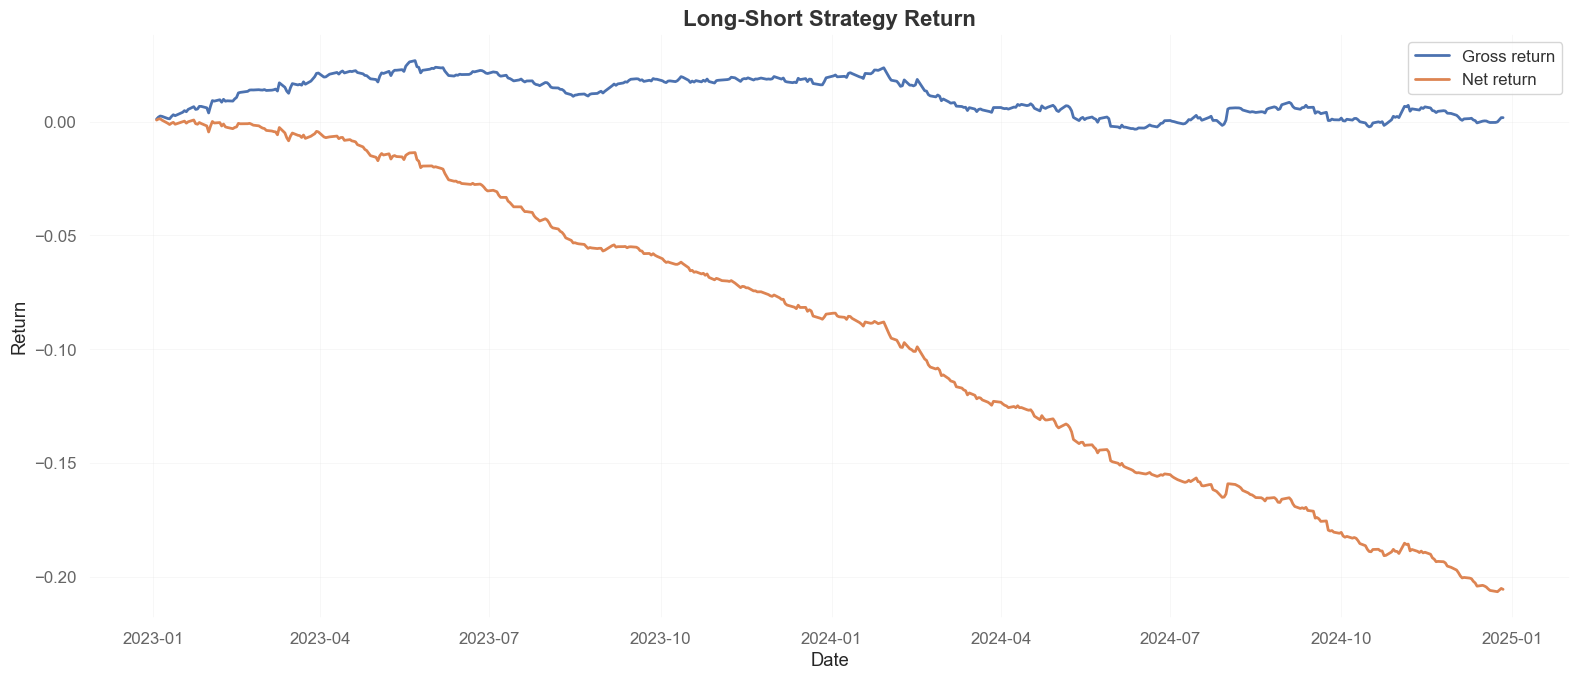

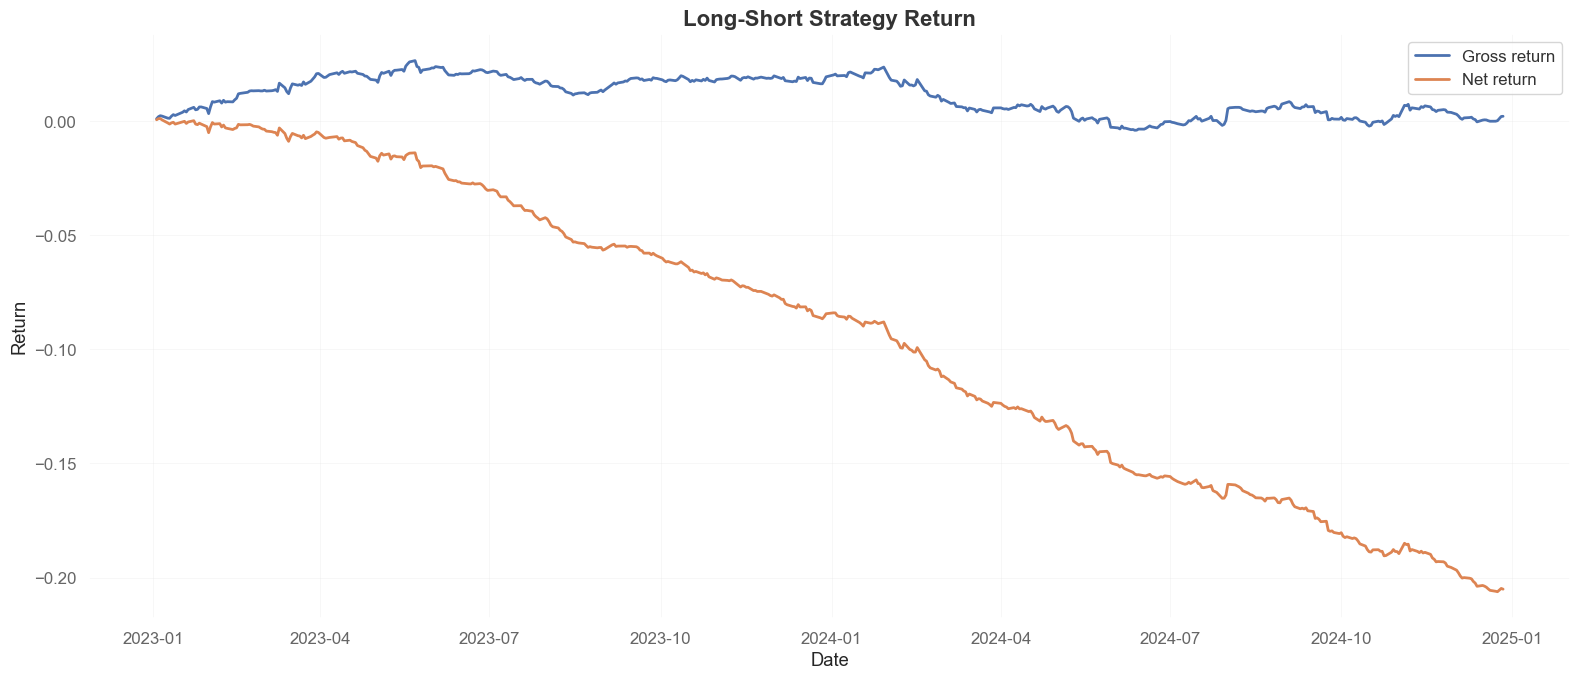

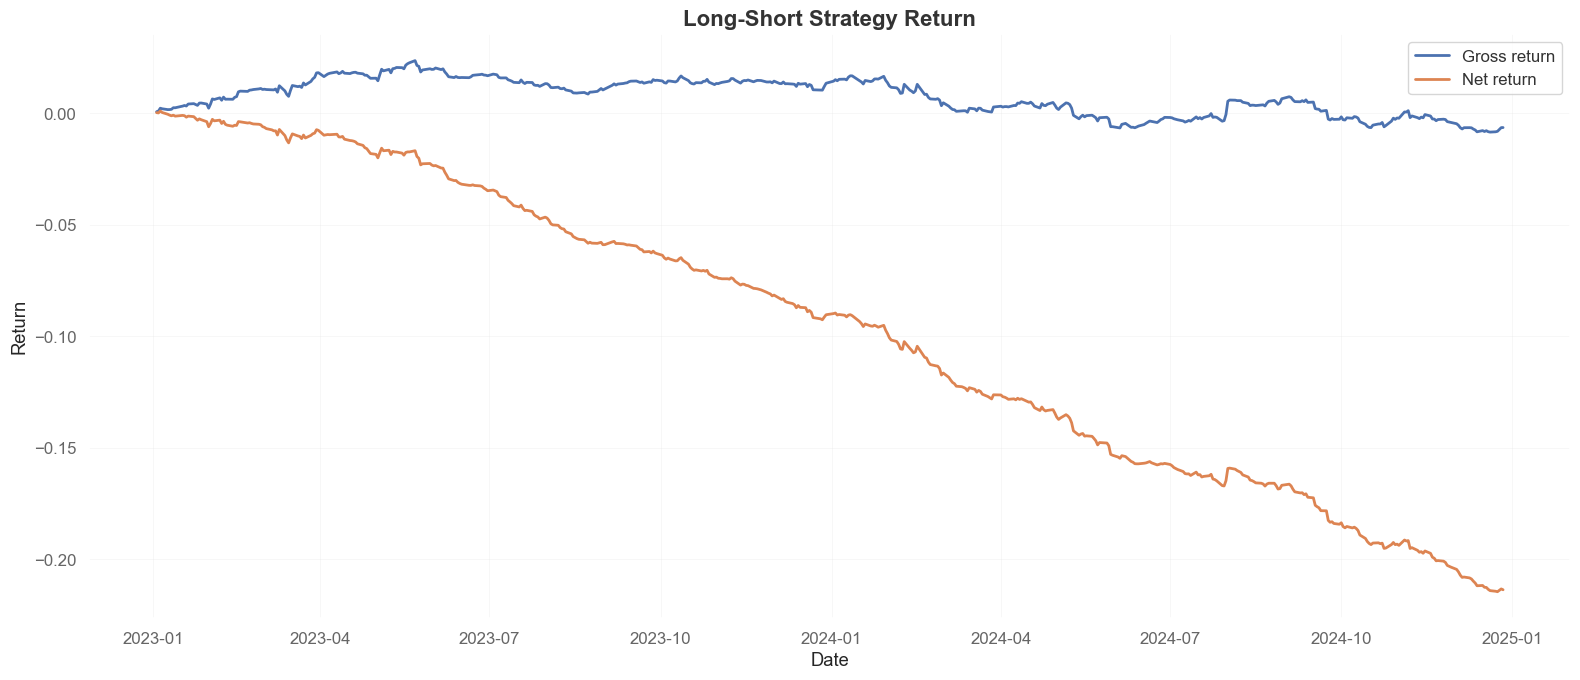

Headline performance by AUM:


,gross,after_commission,after_slippage,net,aum_label,commission_bps,total_trading_cost_bps_override
n_days,500,500,500,500,50m,1.0,4.0
total_return,0.001754,-0.048246,-0.198246,-0.205584,50m,1.0,4.0
annualized_return,0.000884,-0.024316,-0.099916,-0.103614,50m,1.0,4.0
annualized_volatility,0.016027,0.016027,0.016027,0.016025,50m,1.0,4.0
sharpe,0.055174,-1.517189,-6.234277,-6.465759,50m,1.0,4.0
max_drawdown,-0.029358,-0.066035,-0.200326,-0.207587,50m,1.0,4.0
calmar,0.03012,-0.368223,-0.498766,-0.499137,50m,1.0,4.0
win_rate,0.478,0.43,0.316,0.308,50m,1.0,4.0
avg_daily_return,0.000004,-0.000096,-0.000396,-0.000411,50m,1.0,4.0
daily_volatility,0.00101,0.00101,0.00101,0.001009,50m,1.0,4.0


Gross-to-net Sharpe degradation by cost component:


,aum_label,gross_sharpe,after_commission_sharpe,after_slippage_sharpe,net_sharpe,commission_sharpe_points,slippage_sharpe_points,borrow_sharpe_points,total_gross_to_net_sharpe_points,avg_daily_commission_cost,avg_daily_slippage_cost,avg_daily_borrow_cost,avg_daily_trading_cost,commission_bps,avg_slippage_bps,avg_total_trading_cost_bps
0,50m,0.055174,-1.517189,-6.234277,-6.465759,1.572363,4.717088,0.231482,6.520932,0.0001,0.0003,0.000015,0.0004,1.0,3.0,4.0
1,250m,0.070058,-1.503850,-6.225576,-6.456931,1.573908,4.721725,0.231355,6.526989,0.0001,0.0003,0.000015,0.0004,1.0,3.0,4.0
2,1b,-0.203109,-1.772368,-6.480144,-6.704335,1.569259,4.707776,0.224191,6.501226,0.0001,0.0003,0.000014,0.0004,1.0,3.0,4.0


In [279]:
eligibility_by_aum = {
    "50m": eligibility_50m,
    "250m": eligibility_250m,
    "1b": eligibility_1b,
}

import warnings
warnings.simplefilter("ignore", FutureWarning)

# Cost split assumption for gross-to-net Sharpe decomposition.
# The current eligibility files store commission + slippage together as slippage_commission_bps.
# Here, 1 bp is treated as commission and the remaining bps are treated as slippage.
commission_bps_assumption = 1.0
total_trading_cost_bps_override = 4.0

signal_by_aum = {}
daily_ret_by_aum = {}
performance_by_aum = {}
sharpe_degradation_by_aum = {}

for aum_label, eligibility_df in eligibility_by_aum.items():
    signal_df, daily_ret, performance_table, degradation_table = run_backtest_for_one_aum(
        predictions=predictions_rf_cls,
        eligibility_df=eligibility_df,
        df_hardtoborrow=df_hardtoborrow,
        aum_label=aum_label,
        n_long=200,
        n_short=200,
        figure_dir="figures",
        commission_bps=commission_bps_assumption,
        total_trading_cost_bps_override=total_trading_cost_bps_override,
    )

    signal_by_aum[aum_label] = signal_df
    daily_ret_by_aum[aum_label] = daily_ret
    performance_by_aum[aum_label] = performance_table
    sharpe_degradation_by_aum[aum_label] = degradation_table

performance_summary = pd.concat(
    performance_by_aum.values(),
    axis=0,
)

sharpe_degradation_summary = pd.concat(
    sharpe_degradation_by_aum.values(),
    axis=0,
    ignore_index=True,
)

from pathlib import Path
Path("prediction").mkdir(parents=True, exist_ok=True)
performance_summary.to_csv("prediction/rf_cls_performance_summary_by_aum.csv")
sharpe_degradation_summary.to_csv("prediction/rf_cls_sharpe_degradation_by_aum.csv", index=False)

print("Headline performance by AUM:")
display(performance_summary)

print("Gross-to-net Sharpe degradation by cost component:")
display(sharpe_degradation_summary)


## 6-4 QuantStats tear-sheet for the 250M strategy

Generate a QuantStats HTML tear-sheet for the 250M net strategy return, benchmarked against `SP500_TR` using the already prepared `sp_ret_1` benchmark return. The report is restricted to the 2010-2024 window and saved as an HTML file for submission.


In [273]:
# QuantStats HTML tear-sheet for the 250M strategy benchmarked against SP500_TR.
# Strategy return: daily_ret_by_aum["250m"]["portfolio_return_net"]
# Benchmark return: sp500["sp_ret_1"]

from pathlib import Path

try:
    import quantstats as qs
except ImportError as exc:
    raise ImportError(
        "QuantStats is required for this tear-sheet. Install it with `pip install quantstats` "
        "in the notebook environment, then rerun this cell."
    ) from exc

Path("reports").mkdir(parents=True, exist_ok=True)
Path("prediction").mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Prepare 250M strategy returns
# -----------------------------
strategy_250m = daily_ret_by_aum["250m"].copy()
strategy_250m["date"] = pd.to_datetime(strategy_250m["date"]).dt.normalize()

strategy_returns = (
    strategy_250m
    .set_index("date")["portfolio_return_net"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 2. Prepare SP500_TR benchmark returns
# -----------------------------
benchmark_returns = sp500.copy()
benchmark_returns["date"] = pd.to_datetime(benchmark_returns["date"]).dt.normalize()

benchmark_returns = (
    benchmark_returns
    .set_index("date")["sp_ret_1"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 3. Restrict to the coursework window and align dates
# -----------------------------
start_date = pd.Timestamp("2010-01-01")
end_date = pd.Timestamp("2024-12-31")

strategy_returns = strategy_returns.loc[
    (strategy_returns.index >= start_date)
    & (strategy_returns.index <= end_date)
].dropna()

benchmark_returns = benchmark_returns.loc[
    (benchmark_returns.index >= start_date)
    & (benchmark_returns.index <= end_date)
].dropna()

tear_sheet_input = pd.concat(
    [
        strategy_returns.rename("strategy_250m_net"),
        benchmark_returns.rename("SP500_TR"),
    ],
    axis=1,
    join="inner",
).dropna()

if tear_sheet_input.empty:
    raise ValueError(
        "No overlapping strategy and SP500_TR benchmark returns are available "
        "inside the 2010-2024 window."
    )

strategy_qs = tear_sheet_input["strategy_250m_net"]
benchmark_qs = tear_sheet_input["SP500_TR"]

# QuantStats works best with timezone-naive datetime indexes.
strategy_qs.index = pd.to_datetime(strategy_qs.index).tz_localize(None)
benchmark_qs.index = pd.to_datetime(benchmark_qs.index).tz_localize(None)

# -----------------------------
# 4. Save aligned inputs and generate HTML tear-sheet
# -----------------------------
tear_sheet_input.to_csv("prediction/quantstats_250m_strategy_vs_sp500_inputs.csv")

quantstats_html_path = "reports/quantstats_250m_strategy_vs_sp500_2010_2024.html"

qs.reports.html(
    returns=strategy_qs,
    benchmark=benchmark_qs,
    title="250M RF Strategy vs SP500_TR, 2010-2024",
    output=quantstats_html_path,
    download_filename=quantstats_html_path,
)

print(f"QuantStats tear-sheet saved to: {quantstats_html_path}")
print(f"Aligned return window: {tear_sheet_input.index.min().date()} to {tear_sheet_input.index.max().date()}")
print(f"Number of aligned return days: {len(tear_sheet_input)}")



QuantStats tear-sheet saved to: reports/quantstats_250m_strategy_vs_sp500_2010_2024.html
Aligned return window: 2019-01-02 to 2024-12-27
Number of aligned return days: 1508
